# All Interesting Variables Compare in Different Regions in Salish Sea (flux)

Using HRDPS results from `/ocean`, generated lately with `flux` on. 

## Region 

Print the index of interesting regions inside Salish sea. Indexes copied from https://github.com/SalishSeaCast/analysis-junqi/blob/main/Analysis_Atmospheric_Forcing/Analysis_results_comparison/00Mar2023_flux/00Mar2023_SST.ipynb

Locations Added to the Map section.

In [ ]:
# Stations
# ============================================================
# stations = {
#     'Pam Rocks': {
#         'y': 502,
#         'x': 341,
#         'lat': 49.487434,
#         'lon': -123.30153,
#     },

#     'Sand Heads': {
#         'y': 428,
#         'x': 293,
#         'lat': 49.107586,
#         'lon': -123.30203,
#     },
# }

### Map

The codes below were modified from https://github.com/SalishSeaCast/Suchyetal_MHWpaper/blob/main/MHW_Code_For_Publishing/Figure1_MapModelDomain_MHW.ipynb

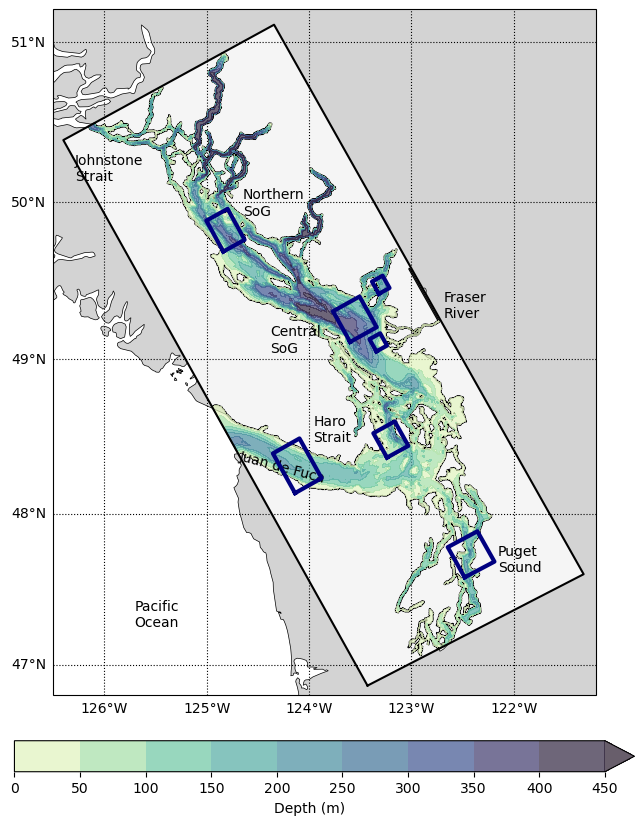

In [3]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cmocean
import cartopy.feature as cfeature
from cartopy import crs, feature
from cartopy.mpl.gridliner import (
    LONGITUDE_FORMATTER,
    LATITUDE_FORMATTER,
)

# ============================================================
# 1. Load model grid / mask
# ============================================================

grid = xr.open_dataset(
    "/ocean/ksuchy/MOAD/NEMO-forcing/grid/bathymetry_202108.nc",
    mask_and_scale=False,
)

mask = xr.open_dataset(
    "/ocean/ksuchy/MOAD/NEMO-forcing/grid/mesh_mask202108.nc"
)

lon = grid.nav_lon.values
lat = grid.nav_lat.values
bathy = grid.Bathymetry.values

# Surface ocean mask:
# 1 = water, 0 = land
tmask = mask.tmask[0, 0, :, :].values


# ============================================================
# 2. Helper: draw a box defined in NEMO grid-index space
# ============================================================

def plot_grid_box(ax, j0, j1, i0, i1,
                  color="navy", linewidth=3):
    """
    Draw a rectangular region whose bounds are given by
    NEMO grid indices.

    j0, j1 : y-index limits
    i0, i1 : x-index limits
    """

    corners = [
        (j0, i0),
        (j0, i1),
        (j1, i1),
        (j1, i0),
        (j0, i0),
    ]

    box_lon = [lon[j, i] for j, i in corners]
    box_lat = [lat[j, i] for j, i in corners]

    ax.plot(
        box_lon,
        box_lat,
        color=color,
        linewidth=linewidth,
        transform=crs.PlateCarree(),
        zorder=5,
    )


# ============================================================
# 3. Make map
# ============================================================

xlim = [-126.5, -121.2]
ylim = [46.8, 51.2]

fig, ax = plt.subplots(
    figsize=(8, 10),
    subplot_kw={
        "projection": crs.Mercator(
            central_longitude=np.mean(xlim)
        )
    },
)

ax.set_extent(
    [xlim[0], xlim[1], ylim[0], ylim[1]],
    crs=crs.PlateCarree(),
)


# ============================================================
# 4. Geographic coastline / land
# ============================================================

# ax.add_feature(
#     feature.GSHHSFeature(
#         scale="full",
#         edgecolor="black",
#         facecolor="lightgrey",
#     ),
#     zorder=0,
# )

ax.add_feature(
    cfeature.LAND.with_scale("10m"),
    facecolor="lightgrey",
    edgecolor="black",
    linewidth=0.5,
    zorder=0,
)


# ============================================================
# 5. Model domain land/water boundary
# ============================================================

# Similar to the original notebook:
# overlay the model mask to show the actual NEMO model domain.

ax.contourf(
    lon,
    lat,
    tmask,
    levels=[-0.01, 0.01],
    colors=["whitesmoke"],
    transform=crs.PlateCarree(),
    zorder=1,
)

ax.contour(
    lon,
    lat,
    tmask,
    levels=[0.01],
    colors="black",
    linewidths=0.8,
    transform=crs.PlateCarree(),
    zorder=2,
)


# ============================================================
# 6. Draw outer model-domain boundary
# ============================================================

domain_corners = [
    (0, 0),
    (0, -1),
    (-1, -1),
    (-1, 0),
    (0, 0),
]

domain_lon = [lon[j, i] for j, i in domain_corners]
domain_lat = [lat[j, i] for j, i in domain_corners]

ax.plot(
    domain_lon,
    domain_lat,
    "k-",
    linewidth=1.5,
    transform=crs.PlateCarree(),
    zorder=4,
)


# ============================================================
# 7. Bathymetry
# ============================================================

# Mask land cells
bathy_masked = np.ma.masked_where(
    tmask == 0,
    bathy,
)

depth_levels = np.arange(0, 451, 50)

c = ax.contourf(
    lon,
    lat,
    bathy_masked,
    levels=depth_levels,
    cmap=cmocean.cm.deep,
    extend="max",
    alpha=0.7,
    transform=crs.PlateCarree(),
    zorder=3,
)


# ============================================================
# 8. Draw study-region boxes
# ============================================================

# These are copied from the original notebook.
# Format:
# name: (j0, j1, i0, i1)

regions = {
    "Central SoG":  (450, 500, 250, 300),
    "Juan de Fuca": (300, 365,  50, 100),
    "Haro Strait":  (280, 320, 210, 250),
    "Northern SoG": (650, 700, 140, 180),
    "Puget Sound":  (75,  125, 225, 280),
    "Pam Rocks": (490, 510, 330, 350),
    "SandHeads": (420, 440, 280, 300),
}

for name, (j0, j1, i0, i1) in regions.items():
    plot_grid_box(
        ax,
        j0, j1,
        i0, i1,
        color="navy",
        linewidth=3,
    )


# ============================================================
# 9. Gridlines
# ============================================================

xlocs = np.arange(
    np.floor(xlim[0]),
    np.ceil(xlim[1]) + 1,
    1,
)

ylocs = np.arange(
    np.floor(ylim[0]),
    np.ceil(ylim[1]) + 1,
    1,
)

gl = ax.gridlines(
    draw_labels=True,
    xlocs=xlocs,
    ylocs=ylocs,
    linestyle=":",
    color="black",
)

gl.xformatter = LONGITUDE_FORMATTER
gl.yformatter = LATITUDE_FORMATTER
gl.top_labels = False
gl.right_labels = False


# ============================================================
# 10. Labels
# ============================================================

# These positions are axis-relative.
ax.text(
    0.15, 0.10,
    "Pacific\nOcean",
    transform=ax.transAxes,
)

ax.text(
    0.82, 0.18,
    "Puget\nSound",
    transform=ax.transAxes,
)

ax.text(
    0.34, 0.31,
    "Juan de Fuca",
    rotation=-15,
    transform=ax.transAxes,
)

ax.text(
    0.40, 0.50,
    "Central\nSoG",
    transform=ax.transAxes,
)

ax.text(
    0.35, 0.70,
    "Northern\nSoG",
    transform=ax.transAxes,
)

ax.text(
    0.04, 0.75,
    "Johnstone\nStrait",
    transform=ax.transAxes,
)

ax.text(
    0.48, 0.37,
    "Haro\nStrait",
    transform=ax.transAxes,
)

ax.text(
    0.72, 0.55,
    "Fraser\nRiver",
    transform=ax.transAxes,
)


# ============================================================
# 11. Colorbar
# ============================================================

cbar = fig.colorbar(
    c,
    ax=ax,
    orientation="horizontal",
    pad=0.06,
    fraction=0.05,
)

cbar.set_label("Depth (m)")


# ============================================================
# 12. Show
# ============================================================

# plt.savefig(
#     "Figure1_StudyAreaMap_clean.png",
#     dpi=300,
#     bbox_inches="tight",
# )

plt.show()

### Region Defination

```
regions = {
    "Central SoG":  (450, 500, 250, 300),
    "Juan de Fuca": (300, 365,  50, 100),
    "Haro Strait":  (280, 320, 210, 250),
    "Northern SoG": (650, 700, 140, 180),
    "Puget Sound":  (75,  125, 225, 280),
    "Pam Rocks": (490, 510, 330, 350),
    "SandHeads": (420, 440, 280, 300),
}
```

Format:(j0, j1, i0, i1)

    j0, j1 : y-index limits
    
    i0, i1 : x-index limits

### Paths

In [ ]:
# Example path for HRDPS 2.5, HRDPS 1, CaSR, HRDPS 10 driven results
# Available months: Mar, Jun, Sep, Dec in 2023

# HRDPS 2.5 (one file for a day):
# base = '/results2/SalishSea/nowcast-green.202111'
# date_str = f'2023{month_num:02d}{day_num:02d}'

    # folder = (
    #     f'{day_num:02d}'
    #     f'{month_str}'
    #     f'23'
    # )

    # filename = (
    #     f'SalishSea_1d_'
    #     f'{date_str}_{date_str}_grid_T.nc'
    # )

    # return os.path.join(
    #     base,
    #     folder,
    #     filename
    # )

# CaSR:
# path_CaSR_mar_biol='/ocean/jqiu/results/Flux/flux_00mar23_CaSR/SalishSea_1d_20230301_20230331_biol_T.nc'

# HRDPS 1:
# path='/ocean/jqiu/results/Flux/flux_00mar23_hrdps1/SalishSea_1d_20230301_20230328_grid_T.nc'
# for Mar, only 01-28 are available
# jun, sep and dec are okay

# HRDPS 10:
# path=    '/ocean/jqiu/results/Flux/flux_00mar23_hrdps10/SalishSea_1d_20230301_20230331_grid_T.nc'

## Extract Information

SSS, halocline depth and strength (how deep and steep), RMSE velocity averaged over the surface (or in boxes), near surface nitrate, diatoms and flagellates.

### Where to find variables

In [3]:
# Biol variables

import xarray as xr

example_path_biol='/ocean/jqiu/results/Flux/flux_00mar23_CaSR/SalishSea_1d_20230301_20230331_biol_T.nc'

example_ds_biol=xr.open_dataset(example_path_biol)

# print(example_ds_biol)


with xr.set_options(display_max_rows=1000):
    print(example_ds_biol)

<xarray.Dataset> Size: 18GB
Dimensions:                       (y: 898, x: 398, nvertex: 4, deptht: 40,
                                   axis_nbounds: 2, time_counter: 31)
Coordinates:
    nav_lat                       (y, x) float32 1MB ...
    nav_lon                       (y, x) float32 1MB ...
  * deptht                        (deptht) float32 160B 0.5 1.5 ... 414.5 441.5
    time_centered                 (time_counter) datetime64[ns] 248B ...
  * time_counter                  (time_counter) datetime64[ns] 248B 2023-03-...
Dimensions without coordinates: y, x, nvertex, axis_nbounds
Data variables:
    bounds_nav_lon                (y, x, nvertex) float32 6MB ...
    bounds_nav_lat                (y, x, nvertex) float32 6MB ...
    area                          (y, x) float32 1MB ...
    deptht_bounds                 (deptht, axis_nbounds) float32 320B ...
    time_centered_bounds          (time_counter, axis_nbounds) datetime64[ns] 496B ...
    time_counter_bounds           (time_

In [2]:
# Physical variables

import xarray as xr

example_path_phy='/ocean/jqiu/results/Flux/flux_00mar23_hrdps10/SalishSea_1d_20230301_20230331_grid_T.nc'

example_ds_phy=xr.open_dataset(example_path_phy)

print(example_ds_phy)

<xarray.Dataset> Size: 7GB
Dimensions:               (y: 898, x: 398, nvertex: 4, deptht: 40,
                           axis_nbounds: 2, time_counter: 31)
Coordinates:
    nav_lat               (y, x) float32 1MB ...
    nav_lon               (y, x) float32 1MB ...
  * deptht                (deptht) float32 160B 0.5 1.5 2.5 ... 414.5 441.5
    time_centered         (time_counter) datetime64[ns] 248B ...
  * time_counter          (time_counter) datetime64[ns] 248B 2023-03-01T12:00...
Dimensions without coordinates: y, x, nvertex, axis_nbounds
Data variables:
    bounds_nav_lon        (y, x, nvertex) float32 6MB ...
    bounds_nav_lat        (y, x, nvertex) float32 6MB ...
    area                  (y, x) float32 1MB ...
    deptht_bounds         (deptht, axis_nbounds) float32 320B ...
    time_centered_bounds  (time_counter, axis_nbounds) datetime64[ns] 496B ...
    time_counter_bounds   (time_counter, axis_nbounds) datetime64[ns] 496B ...
    sossheig              (time_counter, y, x)

In [4]:
# Velocity variables

# HRDPS 2.5 has 1h velocity only:

# path_base_hrdps=Path("/results2/SalishSea/nowcast-green.202111")

# filelist_hrdps_u=sorted(path_base_hrdps.glob("*mar23/SalishSea_1h_202303*_202303*_grid_U.nc"))
# filelist_hrdps_v=sorted(path_base_hrdps.glob("*mar23/SalishSea_1h_202303*_202303*_grid_V.nc"))

example_path_u = '/ocean/jqiu/results/CaSR/00mar23/SalishSea_1h_20230301_20230331_grid_U.nc'
example_path_v = '/ocean/jqiu/results/CaSR/00mar23/SalishSea_1h_20230301_20230331_grid_V.nc'


In [5]:

example_ds_u=xr.open_dataset(example_path_u)

print(example_ds_u)

<xarray.Dataset> Size: 43GB
Dimensions:               (y: 898, x: 398, nvertex: 4, depthu: 40,
                           axis_nbounds: 2, time_counter: 744)
Coordinates:
    nav_lat               (y, x) float32 1MB ...
    nav_lon               (y, x) float32 1MB ...
  * depthu                (depthu) float32 160B 0.5 1.5 2.5 ... 414.5 441.5
    time_centered         (time_counter) datetime64[ns] 6kB ...
  * time_counter          (time_counter) datetime64[ns] 6kB 2023-03-01T00:30:...
Dimensions without coordinates: y, x, nvertex, axis_nbounds
Data variables:
    bounds_nav_lon        (y, x, nvertex) float32 6MB ...
    bounds_nav_lat        (y, x, nvertex) float32 6MB ...
    area                  (y, x) float32 1MB ...
    depthu_bounds         (depthu, axis_nbounds) float32 320B ...
    time_centered_bounds  (time_counter, axis_nbounds) datetime64[ns] 12kB ...
    time_counter_bounds   (time_counter, axis_nbounds) datetime64[ns] 12kB ...
    vozocrtx              (time_counter, dept

In [6]:
example_ds_v=xr.open_dataset(example_path_v)

print(example_ds_v)

<xarray.Dataset> Size: 43GB
Dimensions:               (y: 898, x: 398, nvertex: 4, depthv: 40,
                           axis_nbounds: 2, time_counter: 744)
Coordinates:
    nav_lat               (y, x) float32 1MB ...
    nav_lon               (y, x) float32 1MB ...
  * depthv                (depthv) float32 160B 0.5 1.5 2.5 ... 414.5 441.5
    time_centered         (time_counter) datetime64[ns] 6kB ...
  * time_counter          (time_counter) datetime64[ns] 6kB 2023-03-01T00:30:...
Dimensions without coordinates: y, x, nvertex, axis_nbounds
Data variables:
    bounds_nav_lon        (y, x, nvertex) float32 6MB ...
    bounds_nav_lat        (y, x, nvertex) float32 6MB ...
    area                  (y, x) float32 1MB ...
    depthv_bounds         (depthv, axis_nbounds) float32 320B ...
    time_centered_bounds  (time_counter, axis_nbounds) datetime64[ns] 12kB ...
    time_counter_bounds   (time_counter, axis_nbounds) datetime64[ns] 12kB ...
    vomecrty              (time_counter, dept

### Region

halocline: consider the maximum of absolute d(vosaline)/e3t. Average depth first and divide by depth for each layer (e3t).

Area variable for each grid is `area`.

Data save to `/home/jqiu/analysis-junqi/Analysis_Atmospheric_Forcing/Analysis_results_comparison/00MMM2023/Data_all_compare`.

```
regions = {
    "Central SoG":  (450, 500, 250, 300),
    "Juan de Fuca": (300, 365,  50, 100),
    "Haro Strait":  (280, 320, 210, 250),
    "Northern SoG": (650, 700, 140, 180),
    "Puget Sound":  (75,  125, 225, 280),
    "Pam Rocks": (490, 510, 330, 350),
    "SandHeads": (420, 440, 280, 300),
}
```

Format:(j0, j1, i0, i1)

    j0, j1 : y-index limits
    
    i0, i1 : x-index limits

### Salinity Structure

In [2]:
import xarray as xr
import numpy as np

ds_t=xr.open_dataset("/ocean/jqiu/results/Flux/flux_00mar23_CaSR/SalishSea_1d_20230301_20230331_grid_T.nc")

# 随便选一个时间和空间点
target_date = "2023-03-15"
y_idx = 495
x_idx = 340

sal = ds_t["vosaline"].sel(
    time_counter=target_date,
    method="nearest"
).isel(
    y=y_idx,
    x=x_idx
).compute()

e3t = ds_t["e3t"].sel(
    time_counter=target_date,
    method="nearest"
).isel(
    y=y_idx,
    x=x_idx
).compute()

print("time =", sal["time_counter"].values)
print("y, x =", y_idx, x_idx)

print("\nvosaline _FillValue:")
print(ds_t["vosaline"].encoding.get("_FillValue", "not found"))

print("\n" + "=" * 75)
print(f"{'k':>3} {'depth(m)':>12} {'salinity':>18} {'e3t':>15} {'isnan':>8}")
print("-" * 75)

for k in range(sal.sizes["deptht"]):
    s = sal.values[k]
    h = e3t.values[k]
    z = sal["deptht"].values[k]

    print(
        f"{k:3d} "
        f"{z:12.3f} "
        f"{s:18.10g} "
        f"{h:15.8g} "
        f"{str(np.isnan(s)):>8}"
    )

time = 2023-03-15T12:00:00.000000000
y, x = 495 340

vosaline _FillValue:
1e+20

  k     depth(m)           salinity             e3t    isnan
---------------------------------------------------------------------------
  0        0.500        24.53528786       1.0011412    False
  1        1.500        24.62048721       1.0011451    False
  2        2.500        24.79021645       1.0011526    False
  3        3.500        24.98750687       1.0011673    False
  4        4.500        25.18262291       1.0011959    False
  5        5.500        25.49311829       1.0012515    False
  6        6.500        25.83768654       1.0013598    False
  7        7.501        26.43728638       1.0015708    False
  8        8.501        27.34409523       1.0019817    False
  9        9.502        28.02101326       1.0027821    False
 10       10.505        28.57707214       1.0043409    False
 11       11.509        28.96700859       1.0073763    False
 12       12.518        29.22202873       1.013286

## Extraction

### Bio Extraction

In [ ]:
from pathlib import Path
import glob
import re
import warnings

import pandas as pd
import xarray as xr

from dask import compute
from dask.distributed import Client, LocalCluster

warnings.filterwarnings("ignore", category=UserWarning)

# ============================================================
# 1. SETTINGS
# ============================================================

AREA_SOURCE_EXPERIMENT = "CaSR"

OUTPUT_DIR = Path(
    "/home/jqiu/analysis-junqi/"
    "Analysis_Atmospheric_Forcing/"
    "Analysis_results_comparison/"
    "00MMM2023/Data_all_compare/biology"
)

REGIONS = {
    "Central SoG":  (450, 500, 250, 300),
    "Juan de Fuca": (300, 365,  50, 100),
    "Haro Strait":  (280, 320, 210, 250),
    "Northern SoG": (650, 700, 140, 180),
    "Puget Sound":  (75,  125, 225, 280),
    "Pam Rocks":    (490, 510, 330, 350),
    "SandHeads":    (420, 440, 280, 300),
}

N_WORKERS = 1
THREADS_PER_WORKER = 4
USE_PROCESSES = False

SPATIAL_CHUNK_Y = 128
SPATIAL_CHUNK_X = 128
T_TIME_CHUNK = 7

EXPERIMENTS = {
    "HRDPS2.5": {
        "BIOL": (
            "/ocean/jqiu/results/Flux/flux_00mar23_hrdps2.5/"
            "SalishSea_1d_20230301_20230331_biol_T.nc"
        ),
    },
    "HRDPS1": {
        "BIOL": (
            "/ocean/jqiu/results/Flux/flux_00mar23_hrdps1/"
            "SalishSea_1d_20230301_20230328_biol_T.nc"
        ),
    },
    "CaSR": {
        "BIOL": (
            "/ocean/jqiu/results/Flux/flux_00mar23_CaSR/"
            "SalishSea_1d_20230301_20230331_biol_T.nc"
        ),
    },
    "HRDPS10": {
        "BIOL": (
            "/ocean/jqiu/results/Flux/flux_00mar23_hrdps10/"
            "SalishSea_1d_20230301_20230331_biol_T.nc"
        ),
    },
}

# Area is still taken from CaSR grid_T, exactly as in the original program.
AREA_T_SPEC = (
    "/ocean/jqiu/results/Flux/flux_00mar23_CaSR/"
    "SalishSea_1d_20230301_20230331_grid_T.nc"
)


# ============================================================
# 2. HELPERS
# ============================================================

def safe_filename(name):
    name = re.sub(r"\s+", "_", name.strip())
    name = re.sub(r"[^A-Za-z0-9_.-]+", "_", name)
    return name.strip("_")


def expand_files(spec):
    specs = [spec] if isinstance(spec, (str, Path)) else list(spec)
    files = []
    for item in specs:
        files.extend(glob.glob(str(item)))
    return sorted(set(files))


def open_biol_files(spec, label):
    """Open one experiment's BIOL files lazily."""
    files = expand_files(spec)
    if not files:
        raise FileNotFoundError(f"No files found for {label}:\n{spec}")

    chunks = {
        "time_counter": T_TIME_CHUNK,
        "y": SPATIAL_CHUNK_Y,
        "x": SPATIAL_CHUNK_X,
    }

    # We do not need any area variable from BIOL files.
    if len(files) == 1:
        return xr.open_dataset(
            files[0],
            chunks=chunks,
            drop_variables=["area"],
        )

    return xr.open_mfdataset(
        files,
        combine="by_coords",
        parallel=True,
        chunks=chunks,
        drop_variables=["area"],
    )


def load_area_t():
    files = expand_files(AREA_T_SPEC)
    if not files:
        raise FileNotFoundError(
            f"No CaSR T-grid area file found:\n{AREA_T_SPEC}"
        )

    ds = xr.open_dataset(files[0])
    try:
        if "area" not in ds.variables:
            raise KeyError(
                f"CaSR T area source missing 'area'. "
                f"Available: {list(ds.variables)}"
            )
        return ds["area"].load()
    finally:
        ds.close()


def require_vars(ds, variables, label):
    missing = [v for v in variables if v not in ds.variables]
    if missing:
        raise KeyError(
            f"{label} missing variables: {missing}\n"
            f"Available variables: {list(ds.variables)}"
        )


def area_weighted_mean(da, area):
    valid_area = area.where(da.notnull())
    numerator = (da * valid_area).sum(dim=("y", "x"), skipna=True)
    denominator = valid_area.sum(dim=("y", "x"), skipna=True)
    return numerator / denominator


def build_biology_arrays(ds_biol, area_t, region, exp_name):
    """Surface nitrate + diatoms + flagellates."""
    j0, j1, i0, i1 = region

    require_vars(
        ds_biol,
        [
            "nitrate",
            "diatoms",
            "flagellates",
            "deptht",
            "time_counter",
        ],
        f"{exp_name} biology",
    )

    # Pure index-based regional subset: no spatial interpolation.
    b = ds_biol.isel(
        y=slice(j0, j1),
        x=slice(i0, i1),
    )

    nitrate = area_weighted_mean(
        b["nitrate"].isel(deptht=0),
        area_t,
    )
    diatoms = area_weighted_mean(
        b["diatoms"].isel(deptht=0),
        area_t,
    )
    flagellates = area_weighted_mean(
        b["flagellates"].isel(deptht=0),
        area_t,
    )

    return [
        (f"{exp_name}__nitrate_surface", nitrate),
        (f"{exp_name}__diatoms_surface", diatoms),
        (f"{exp_name}__flagellates_surface", flagellates),
    ]


def da_to_daily_dataframe(da, column_name):
    da = da.rename(column_name)
    df = da.to_dataframe().reset_index()
    df["date"] = pd.to_datetime(df["time_counter"]).dt.normalize()
    return df[["date", column_name]]


def merge_frames(frames):
    if not frames:
        return pd.DataFrame(columns=["date"])

    out = frames[0]
    for frame in frames[1:]:
        out = out.merge(frame, on="date", how="outer")

    return out.sort_values("date").reset_index(drop=True)


def add_region_metadata(out, region_name, region):
    j0, j1, i0, i1 = region
    out.insert(1, "region", region_name)
    out["j0"] = j0
    out["j1"] = j1
    out["i0"] = i0
    out["i1"] = i1
    return out


# ============================================================
# 3. MAIN
# ============================================================

def main():
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

    cluster = LocalCluster(
        n_workers=N_WORKERS,
        threads_per_worker=THREADS_PER_WORKER,
        processes=USE_PROCESSES,
        dashboard_address=":0",
    )
    client = Client(cluster)

    print("Dask client started")
    print(f"Dashboard: {client.dashboard_link}")

    frames_by_region = {
        region_name: []
        for region_name in REGIONS
    }

    try:
        print("\nLoading shared T-grid area from CaSR...")
        shared_area_t = load_area_t()
        print("Shared T-grid area loaded.")

        # One experiment opened once, used for all regions, then closed.
        for exp_name, cfg in EXPERIMENTS.items():
            print(f"\nOpening biology data: {exp_name}")
            ds_biol = open_biol_files(
                cfg["BIOL"],
                f"{exp_name} biology",
            )

            try:
                for region_name, region in REGIONS.items():
                    print(
                        f"  {exp_name}: processing biology "
                        f"region {region_name}"
                    )

                    j0, j1, i0, i1 = region
                    area_t = shared_area_t.isel(
                        y=slice(j0, j1),
                        x=slice(i0, i1),
                    )

                    lazy_outputs = build_biology_arrays(
                        ds_biol,
                        area_t,
                        region,
                        exp_name,
                    )

                    names = [name for name, _ in lazy_outputs]
                    arrays = [arr for _, arr in lazy_outputs]

                    # Only 3 output series at a time.
                    computed = compute(*arrays)

                    frames_by_region[region_name].extend(
                        da_to_daily_dataframe(arr, name)
                        for name, arr in zip(names, computed)
                    )

                    del lazy_outputs, arrays, computed

            finally:
                ds_biol.close()
                print(f"Closed biology data: {exp_name}")

        print("\nWriting biology CSV files...")
        for region_name, region in REGIONS.items():
            out = merge_frames(frames_by_region[region_name])
            out = add_region_metadata(out, region_name, region)

            filename = (
                OUTPUT_DIR /
                f"{safe_filename(region_name)}_biology.csv"
            )
            out.to_csv(filename, index=False)
            print(f"  saved -> {filename}")

    finally:
        client.close()
        cluster.close()

    print("\nBiology processing done.")


if __name__ == "__main__":
    main()


### Phy Extraction

In [ ]:
from pathlib import Path
import glob
import re
import warnings

import numpy as np
import pandas as pd
import xarray as xr

from dask import compute
from dask.distributed import Client, LocalCluster

warnings.filterwarnings("ignore", category=UserWarning)

# ============================================================
# 1. SETTINGS
# ============================================================

AREA_SOURCE_EXPERIMENT = "CaSR"

OUTPUT_DIR = Path(
    "/home/jqiu/analysis-junqi/"
    "Analysis_Atmospheric_Forcing/"
    "Analysis_results_comparison/"
    "00MMM2023/Data_all_compare/physical"
)

REGIONS = {
    "Central SoG":  (450, 500, 250, 300),
    "Juan de Fuca": (300, 365,  50, 100),
    "Haro Strait":  (280, 320, 210, 250),
    "Northern SoG": (650, 700, 140, 180),
    "Puget Sound":  (75,  125, 225, 280),
    "Pam Rocks":    (490, 510, 330, 350),
    "SandHeads":    (420, 440, 280, 300),
}

# One worker + several threads avoids the misleading per-worker
# memory limit issue that occurs with processes=False + many workers.
N_WORKERS = 1
THREADS_PER_WORKER = 4
USE_PROCESSES = False

SPATIAL_CHUNK_Y = 128
SPATIAL_CHUNK_X = 128
T_TIME_CHUNK = 7

EXPERIMENTS = {
    "HRDPS2.5": {
        "T": (
            "/ocean/jqiu/results/Flux/flux_00mar23_hrdps2.5/"
            "SalishSea_1d_20230301_20230331_grid_T.nc"
        ),
    },
    "HRDPS1": {
        "T": (
            "/ocean/jqiu/results/Flux/flux_00mar23_hrdps1/"
            "SalishSea_1d_20230301_20230328_grid_T.nc"
        ),
    },
    "CaSR": {
        "T": (
            "/ocean/jqiu/results/Flux/flux_00mar23_CaSR/"
            "SalishSea_1d_20230301_20230331_grid_T.nc"
        ),
    },
    "HRDPS10": {
        "T": (
            "/ocean/jqiu/results/Flux/flux_00mar23_hrdps10/"
            "SalishSea_1d_20230301_20230331_grid_T.nc"
        ),
    },
}


# ============================================================
# 2. HELPERS
# ============================================================

def safe_filename(name):
    name = re.sub(r"\s+", "_", name.strip())
    name = re.sub(r"[^A-Za-z0-9_.-]+", "_", name)
    return name.strip("_")


def expand_files(spec):
    specs = [spec] if isinstance(spec, (str, Path)) else list(spec)
    files = []
    for item in specs:
        files.extend(glob.glob(str(item)))
    return sorted(set(files))


def open_t_files(spec, label, keep_area=False):
    """Open one experiment's T files lazily."""
    files = expand_files(spec)
    if not files:
        raise FileNotFoundError(f"No files found for {label}:\n{spec}")

    chunks = {
        "time_counter": T_TIME_CHUNK,
        "y": SPATIAL_CHUNK_Y,
        "x": SPATIAL_CHUNK_X,
    }
    drop_variables = None if keep_area else ["area"]

    if len(files) == 1:
        return xr.open_dataset(
            files[0],
            chunks=chunks,
            drop_variables=drop_variables,
        )

    return xr.open_mfdataset(
        files,
        combine="by_coords",
        parallel=True,
        chunks=chunks,
        drop_variables=drop_variables,
    )


def require_vars(ds, variables, label):
    missing = [v for v in variables if v not in ds.variables]
    if missing:
        raise KeyError(
            f"{label} missing variables: {missing}\n"
            f"Available variables: {list(ds.variables)}"
        )


def area_weighted_mean(da, area):
    valid_area = area.where(da.notnull())
    numerator = (da * valid_area).sum(dim=("y", "x"), skipna=True)
    denominator = valid_area.sum(dim=("y", "x"), skipna=True)
    return numerator / denominator


def halocline_from_region(salinity, e3t, area):
    # Remove nan
    salinity = salinity.where(salinity > 0)
    sal_profile = area_weighted_mean(salinity, area)
    e3t_profile = area_weighted_mean(e3t, area)

    depth = sal_profile["deptht"]
    if depth.size < 2:
        raise ValueError("Need at least 2 depth levels for halocline.")

    interface_depth = 0.5 * (
        depth.values[:-1] + depth.values[1:]
    )

    d_sal = sal_profile.diff("deptht")
    d_sal = d_sal.assign_coords(deptht=interface_depth)

    thickness = e3t_profile.isel(deptht=slice(0, -1))
    thickness = thickness.assign_coords(deptht=interface_depth)

    gradient = np.abs(d_sal / thickness)
    gradient = gradient.where(np.isfinite(gradient))

    has_valid = gradient.notnull().any("deptht")
    safe_gradient = gradient.fillna(-np.inf)

    max_index = safe_gradient.argmax("deptht")
    strength = gradient.max("deptht", skipna=True)
    halo_depth = gradient["deptht"].isel(deptht=max_index)

    return (
        halo_depth.where(has_valid),
        strength.where(has_valid),
    )


def build_physical_arrays(ds_t, area_t, region, exp_name):
    """SSS + halocline depth + halocline strength."""
    j0, j1, i0, i1 = region

    require_vars(
        ds_t,
        ["vosaline", "e3t", "deptht", "time_counter"],
        f"{exp_name} T",
    )

    # Pure index-based regional subset: no spatial interpolation.
    t = ds_t.isel(
        y=slice(j0, j1),
        x=slice(i0, i1),
    )

    sss = area_weighted_mean(
        t["vosaline"].isel(deptht=0),
        area_t,
    )

    halo_depth, halo_strength = halocline_from_region(
        t["vosaline"],
        t["e3t"],
        area_t,
    )

    return [
        (f"{exp_name}__SSS", sss),
        (f"{exp_name}__halocline_depth_m", halo_depth),
        (
            f"{exp_name}__halocline_strength_psu_per_m",
            halo_strength,
        ),
    ]


def da_to_daily_dataframe(da, column_name):
    da = da.rename(column_name)
    df = da.to_dataframe().reset_index()
    df["date"] = pd.to_datetime(df["time_counter"]).dt.normalize()
    return df[["date", column_name]]


def merge_frames(frames):
    if not frames:
        return pd.DataFrame(columns=["date"])

    out = frames[0]
    for frame in frames[1:]:
        out = out.merge(frame, on="date", how="outer")

    return out.sort_values("date").reset_index(drop=True)


def add_region_metadata(out, region_name, region):
    j0, j1, i0, i1 = region
    out.insert(1, "region", region_name)
    out["j0"] = j0
    out["j1"] = j1
    out["i0"] = i0
    out["i1"] = i1
    return out


# ============================================================
# 3. MAIN
# ============================================================

def main():
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

    cluster = LocalCluster(
        n_workers=N_WORKERS,
        threads_per_worker=THREADS_PER_WORKER,
        processes=USE_PROCESSES,
        dashboard_address=":0",
    )
    client = Client(cluster)

    print("Dask client started")
    print(f"Dashboard: {client.dashboard_link}")
    print(
        f"Workers={N_WORKERS}, "
        f"threads/worker={THREADS_PER_WORKER}, "
        f"processes={USE_PROCESSES}"
    )

    # Each region accumulates only small, already-computed 1-D series.
    frames_by_region = {
        region_name: []
        for region_name in REGIONS
    }

    try:
        # Load the common T-grid area once into memory, then close the NC.
        print("\nLoading shared T-grid area from CaSR...")
        area_ds = open_t_files(
            EXPERIMENTS[AREA_SOURCE_EXPERIMENT]["T"],
            f"{AREA_SOURCE_EXPERIMENT} T area source",
            keep_area=True,
        )
        require_vars(
            area_ds,
            ["area"],
            f"{AREA_SOURCE_EXPERIMENT} T",
        )
        shared_area_t = area_ds["area"].load()
        area_ds.close()
        print("Shared T-grid area loaded.")

        # Open ONE experiment at a time; use it for all 7 regions; then close it.
        for exp_name, cfg in EXPERIMENTS.items():
            print(f"\nOpening physical T data: {exp_name}")
            ds_t = open_t_files(
                cfg["T"],
                f"{exp_name} T",
                keep_area=False,
            )

            try:
                for region_name, region in REGIONS.items():
                    print(
                        f"  {exp_name}: processing physical "
                        f"region {region_name}"
                    )

                    j0, j1, i0, i1 = region
                    area_t = shared_area_t.isel(
                        y=slice(j0, j1),
                        x=slice(i0, i1),
                    )

                    lazy_outputs = build_physical_arrays(
                        ds_t,
                        area_t,
                        region,
                        exp_name,
                    )

                    names = [name for name, _ in lazy_outputs]
                    arrays = [arr for _, arr in lazy_outputs]

                    # Only 3 output series are computed together.
                    computed = compute(*arrays)

                    frames_by_region[region_name].extend(
                        da_to_daily_dataframe(arr, name)
                        for name, arr in zip(names, computed)
                    )

                    del lazy_outputs, arrays, computed

            finally:
                ds_t.close()
                print(f"Closed physical T data: {exp_name}")

        # Save one physical CSV per region.
        print("\nWriting physical CSV files...")
        for region_name, region in REGIONS.items():
            out = merge_frames(frames_by_region[region_name])
            out = add_region_metadata(out, region_name, region)

            filename = (
                OUTPUT_DIR /
                f"{safe_filename(region_name)}_physical.csv"
            )
            out.to_csv(filename, index=False)
            print(f"  saved -> {filename}")

    finally:
        client.close()
        cluster.close()

    print("\nPhysical processing done.")


if __name__ == "__main__":
    main()


### Velocity Extraction

In [ ]:
from pathlib import Path
import glob
import re
import warnings

import numpy as np
import pandas as pd
import xarray as xr

from dask import compute
from dask.distributed import Client, LocalCluster

warnings.filterwarnings("ignore", category=UserWarning)

# ============================================================
# 1. SETTINGS
# ============================================================

REFERENCE_EXPERIMENT = "HRDPS2.5"
AREA_SOURCE_EXPERIMENT = "CaSR"

OUTPUT_DIR = Path(
    "/home/jqiu/analysis-junqi/"
    "Analysis_Atmospheric_Forcing/"
    "Analysis_results_comparison/"
    "00MMM2023/Data_all_compare/velocity"
)

REGIONS = {
    "Central SoG":  (450, 500, 250, 300),
    "Juan de Fuca": (300, 365,  50, 100),
    "Haro Strait":  (280, 320, 210, 250),
    "Northern SoG": (650, 700, 140, 180),
    "Puget Sound":  (75,  125, 225, 280),
    "Pam Rocks":    (490, 510, 330, 350),
    "SandHeads":    (420, 440, 280, 300),
}

N_WORKERS = 1
THREADS_PER_WORKER = 4
USE_PROCESSES = False

SPATIAL_CHUNK_Y = 128
SPATIAL_CHUNK_X = 128

# HRDPS2.5 U/V are hourly.
UV_HOURLY_TIME_CHUNK = 24

# Other experiments are already daily.
UV_DAILY_TIME_CHUNK = 7

EXPERIMENTS = {
    "HRDPS2.5": {
        "U": (
            "/results2/SalishSea/nowcast-green.202111/"
            "*mar23/SalishSea_1h_202303*_202303*_grid_U.nc"
        ),
        "V": (
            "/results2/SalishSea/nowcast-green.202111/"
            "*mar23/SalishSea_1h_202303*_202303*_grid_V.nc"
        ),
    },
    "HRDPS1": {
        "U": (
            "/ocean/jqiu/results/Flux/flux_00mar23_hrdps1/"
            "SalishSea_1d_20230301_20230328_grid_U.nc"
        ),
        "V": (
            "/ocean/jqiu/results/Flux/flux_00mar23_hrdps1/"
            "SalishSea_1d_20230301_20230328_grid_V.nc"
        ),
    },
    "CaSR": {
        "U": (
            "/ocean/jqiu/results/Flux/flux_00mar23_CaSR/"
            "SalishSea_1d_20230301_20230331_grid_U.nc"
        ),
        "V": (
            "/ocean/jqiu/results/Flux/flux_00mar23_CaSR/"
            "SalishSea_1d_20230301_20230331_grid_V.nc"
        ),
    },
    "HRDPS10": {
        "U": (
            "/ocean/jqiu/results/Flux/flux_00mar23_hrdps10/"
            "SalishSea_1d_20230301_20230331_grid_U.nc"
        ),
        "V": (
            "/ocean/jqiu/results/Flux/flux_00mar23_hrdps10/"
            "SalishSea_1d_20230301_20230331_grid_V.nc"
        ),
    },
}


# ============================================================
# 2. HELPERS
# ============================================================

def safe_filename(name):
    name = re.sub(r"\s+", "_", name.strip())
    name = re.sub(r"[^A-Za-z0-9_.-]+", "_", name)
    return name.strip("_")


def expand_files(spec):
    specs = [spec] if isinstance(spec, (str, Path)) else list(spec)
    files = []
    for item in specs:
        files.extend(glob.glob(str(item)))
    return sorted(set(files))


def open_velocity_files(spec, label, exp_name, keep_area=False):
    files = expand_files(spec)
    if not files:
        raise FileNotFoundError(f"No files found for {label}:\n{spec}")

    time_chunk = (
        UV_HOURLY_TIME_CHUNK
        if exp_name == REFERENCE_EXPERIMENT
        else UV_DAILY_TIME_CHUNK
    )

    chunks = {
        "time_counter": time_chunk,
        "y": SPATIAL_CHUNK_Y,
        "x": SPATIAL_CHUNK_X,
    }

    drop_variables = None if keep_area else ["area"]

    if len(files) == 1:
        return xr.open_dataset(
            files[0],
            chunks=chunks,
            drop_variables=drop_variables,
        )

    return xr.open_mfdataset(
        files,
        combine="by_coords",
        parallel=True,
        chunks=chunks,
        drop_variables=drop_variables,
    )


def require_vars(ds, variables, label):
    missing = [v for v in variables if v not in ds.variables]
    if missing:
        raise KeyError(
            f"{label} missing variables: {missing}\n"
            f"Available variables: {list(ds.variables)}"
        )


def load_shared_uv_areas():
    print("Loading shared U/V grid areas from CaSR...")

    ds_u = open_velocity_files(
        EXPERIMENTS[AREA_SOURCE_EXPERIMENT]["U"],
        f"{AREA_SOURCE_EXPERIMENT} U area source",
        AREA_SOURCE_EXPERIMENT,
        keep_area=True,
    )
    ds_v = open_velocity_files(
        EXPERIMENTS[AREA_SOURCE_EXPERIMENT]["V"],
        f"{AREA_SOURCE_EXPERIMENT} V area source",
        AREA_SOURCE_EXPERIMENT,
        keep_area=True,
    )

    try:
        require_vars(
            ds_u,
            ["area"],
            f"{AREA_SOURCE_EXPERIMENT} U",
        )
        require_vars(
            ds_v,
            ["area"],
            f"{AREA_SOURCE_EXPERIMENT} V",
        )

        area_u = ds_u["area"].load()
        area_v = ds_v["area"].load()
        return area_u, area_v

    finally:
        ds_u.close()
        ds_v.close()


def area_weighted_mse(diff, area):
    valid_area = area.where(diff.notnull())
    numerator = (
        (diff ** 2) * valid_area
    ).sum(dim=("y", "x"), skipna=True)
    denominator = valid_area.sum(
        dim=("y", "x"),
        skipna=True,
    )
    return numerator / denominator


def to_daily(da):
    return da.resample(
        time_counter="1D"
    ).mean(skipna=True)


def build_velocity_rmse_arrays(
    ref_u,
    ref_v,
    test_u,
    test_v,
    area_u,
    area_v,
    region,
    exp_name,
):
    """
    Daily surface velocity RMSE for exp_name vs HRDPS2.5.

    Spatial matching is by the same y/x indices.
    No horizontal coordinate interpolation is performed.
    """
    j0, j1, i0, i1 = region

    require_vars(
        ref_u,
        ["vozocrtx", "depthu", "time_counter"],
        f"{REFERENCE_EXPERIMENT} U",
    )
    require_vars(
        ref_v,
        ["vomecrty", "depthv", "time_counter"],
        f"{REFERENCE_EXPERIMENT} V",
    )
    require_vars(
        test_u,
        ["vozocrtx", "depthu", "time_counter"],
        f"{exp_name} U",
    )
    require_vars(
        test_v,
        ["vomecrty", "depthv", "time_counter"],
        f"{exp_name} V",
    )

    # Spatial subset BEFORE daily resampling.
    u_ref = ref_u["vozocrtx"].isel(
        depthu=0,
        y=slice(j0, j1),
        x=slice(i0, i1),
    )
    v_ref = ref_v["vomecrty"].isel(
        depthv=0,
        y=slice(j0, j1),
        x=slice(i0, i1),
    )

    u_test = test_u["vozocrtx"].isel(
        depthu=0,
        y=slice(j0, j1),
        x=slice(i0, i1),
    )
    v_test = test_v["vomecrty"].isel(
        depthv=0,
        y=slice(j0, j1),
        x=slice(i0, i1),
    )

    # HRDPS2.5 is hourly; convert it to daily.
    u_ref = to_daily(u_ref)
    v_ref = to_daily(v_ref)

    # Test experiments are already daily.
    # Normalize timestamps to calendar days.
    u_test = u_test.assign_coords(
        time_counter=u_test["time_counter"].dt.floor("D")
    )
    v_test = v_test.assign_coords(
        time_counter=v_test["time_counter"].dt.floor("D")
    )

    u_ref, u_test = xr.align(
        u_ref,
        u_test,
        join="inner",
    )
    v_ref, v_test = xr.align(
        v_ref,
        v_test,
        join="inner",
    )

    # Keep these lazy; only the final 1-D series are computed.
    u_mse = area_weighted_mse(
        u_test - u_ref,
        area_u,
    )
    v_mse = area_weighted_mse(
        v_test - v_ref,
        area_v,
    )

    return [
        (
            f"{exp_name}__u_rmse_vs_{REFERENCE_EXPERIMENT}_m_per_s",
            np.sqrt(u_mse),
        ),
        (
            f"{exp_name}__v_rmse_vs_{REFERENCE_EXPERIMENT}_m_per_s",
            np.sqrt(v_mse),
        ),
        (
            f"{exp_name}__velocity_rmse_vs_{REFERENCE_EXPERIMENT}_m_per_s",
            np.sqrt(u_mse + v_mse),
        ),
    ]


def da_to_daily_dataframe(da, column_name):
    da = da.rename(column_name)
    df = da.to_dataframe().reset_index()
    df["date"] = pd.to_datetime(df["time_counter"]).dt.normalize()
    return df[["date", column_name]]


def merge_frames(frames):
    if not frames:
        return pd.DataFrame(columns=["date"])

    out = frames[0]
    for frame in frames[1:]:
        out = out.merge(frame, on="date", how="outer")

    return out.sort_values("date").reset_index(drop=True)


def add_region_metadata(out, region_name, region):
    j0, j1, i0, i1 = region
    out.insert(1, "region", region_name)
    out.insert(2, "velocity_reference", REFERENCE_EXPERIMENT)
    out["j0"] = j0
    out["j1"] = j1
    out["i0"] = i0
    out["i1"] = i1
    return out


# ============================================================
# 3. MAIN
# ============================================================

def main():
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

    cluster = LocalCluster(
        n_workers=N_WORKERS,
        threads_per_worker=THREADS_PER_WORKER,
        processes=USE_PROCESSES,
        dashboard_address=":0",
    )
    client = Client(cluster)

    print("Dask client started")
    print(f"Dashboard: {client.dashboard_link}")
    print(
        f"Workers={N_WORKERS}, "
        f"threads/worker={THREADS_PER_WORKER}, "
        f"processes={USE_PROCESSES}"
    )

    frames_by_region = {
        region_name: []
        for region_name in REGIONS
    }

    ref_u = None
    ref_v = None

    try:
        # Area arrays are small enough to load once and detach from NC files.
        shared_area_u, shared_area_v = load_shared_uv_areas()
        print("Shared U/V grid areas loaded.")

        # Keep the hourly reference open ONCE for the whole velocity run.
        print(f"\nOpening reference U/V: {REFERENCE_EXPERIMENT}")
        ref_cfg = EXPERIMENTS[REFERENCE_EXPERIMENT]

        ref_u = open_velocity_files(
            ref_cfg["U"],
            f"{REFERENCE_EXPERIMENT} U",
            REFERENCE_EXPERIMENT,
            keep_area=False,
        )
        ref_v = open_velocity_files(
            ref_cfg["V"],
            f"{REFERENCE_EXPERIMENT} V",
            REFERENCE_EXPERIMENT,
            keep_area=False,
        )

        # Open only ONE test experiment at a time.
        for exp_name, cfg in EXPERIMENTS.items():
            if exp_name == REFERENCE_EXPERIMENT:
                continue

            print(f"\nOpening test U/V: {exp_name}")
            test_u = open_velocity_files(
                cfg["U"],
                f"{exp_name} U",
                exp_name,
                keep_area=False,
            )
            test_v = open_velocity_files(
                cfg["V"],
                f"{exp_name} V",
                exp_name,
                keep_area=False,
            )

            try:
                for region_name, region in REGIONS.items():
                    print(
                        f"  {exp_name}: processing velocity "
                        f"region {region_name}"
                    )

                    j0, j1, i0, i1 = region
                    area_u = shared_area_u.isel(
                        y=slice(j0, j1),
                        x=slice(i0, i1),
                    )
                    area_v = shared_area_v.isel(
                        y=slice(j0, j1),
                        x=slice(i0, i1),
                    )

                    lazy_outputs = build_velocity_rmse_arrays(
                        ref_u,
                        ref_v,
                        test_u,
                        test_v,
                        area_u,
                        area_v,
                        region,
                        exp_name,
                    )

                    names = [name for name, _ in lazy_outputs]
                    arrays = [arr for _, arr in lazy_outputs]

                    # Exactly one experiment + one region:
                    # only 3 final time series are submitted together.
                    computed = compute(*arrays)

                    frames_by_region[region_name].extend(
                        da_to_daily_dataframe(arr, name)
                        for name, arr in zip(names, computed)
                    )

                    del lazy_outputs, arrays, computed

            finally:
                test_u.close()
                test_v.close()
                print(f"Closed test U/V: {exp_name}")

        print("\nWriting velocity CSV files...")
        for region_name, region in REGIONS.items():
            out = merge_frames(frames_by_region[region_name])
            out = add_region_metadata(out, region_name, region)

            filename = (
                OUTPUT_DIR /
                f"{safe_filename(region_name)}_velocity.csv"
            )
            out.to_csv(filename, index=False)
            print(f"  saved -> {filename}")

    finally:
        if ref_u is not None:
            ref_u.close()
        if ref_v is not None:
            ref_v.close()

        client.close()
        cluster.close()

    print("\nVelocity processing done.")


if __name__ == "__main__":
    main()


## Visualization

### Physical

Reading: /home/jqiu/analysis-junqi/Analysis_Atmospheric_Forcing/Analysis_results_comparison/00MMM2023/Data_all_compare/physical/Central_SoG_physical.csv
Reading: /home/jqiu/analysis-junqi/Analysis_Atmospheric_Forcing/Analysis_results_comparison/00MMM2023/Data_all_compare/physical/Juan_de_Fuca_physical.csv
Reading: /home/jqiu/analysis-junqi/Analysis_Atmospheric_Forcing/Analysis_results_comparison/00MMM2023/Data_all_compare/physical/Haro_Strait_physical.csv
Reading: /home/jqiu/analysis-junqi/Analysis_Atmospheric_Forcing/Analysis_results_comparison/00MMM2023/Data_all_compare/physical/Northern_SoG_physical.csv
Reading: /home/jqiu/analysis-junqi/Analysis_Atmospheric_Forcing/Analysis_results_comparison/00MMM2023/Data_all_compare/physical/Puget_Sound_physical.csv
Reading: /home/jqiu/analysis-junqi/Analysis_Atmospheric_Forcing/Analysis_results_comparison/00MMM2023/Data_all_compare/physical/Pam_Rocks_physical.csv
Reading: /home/jqiu/analysis-junqi/Analysis_Atmospheric_Forcing/Analysis_results_c

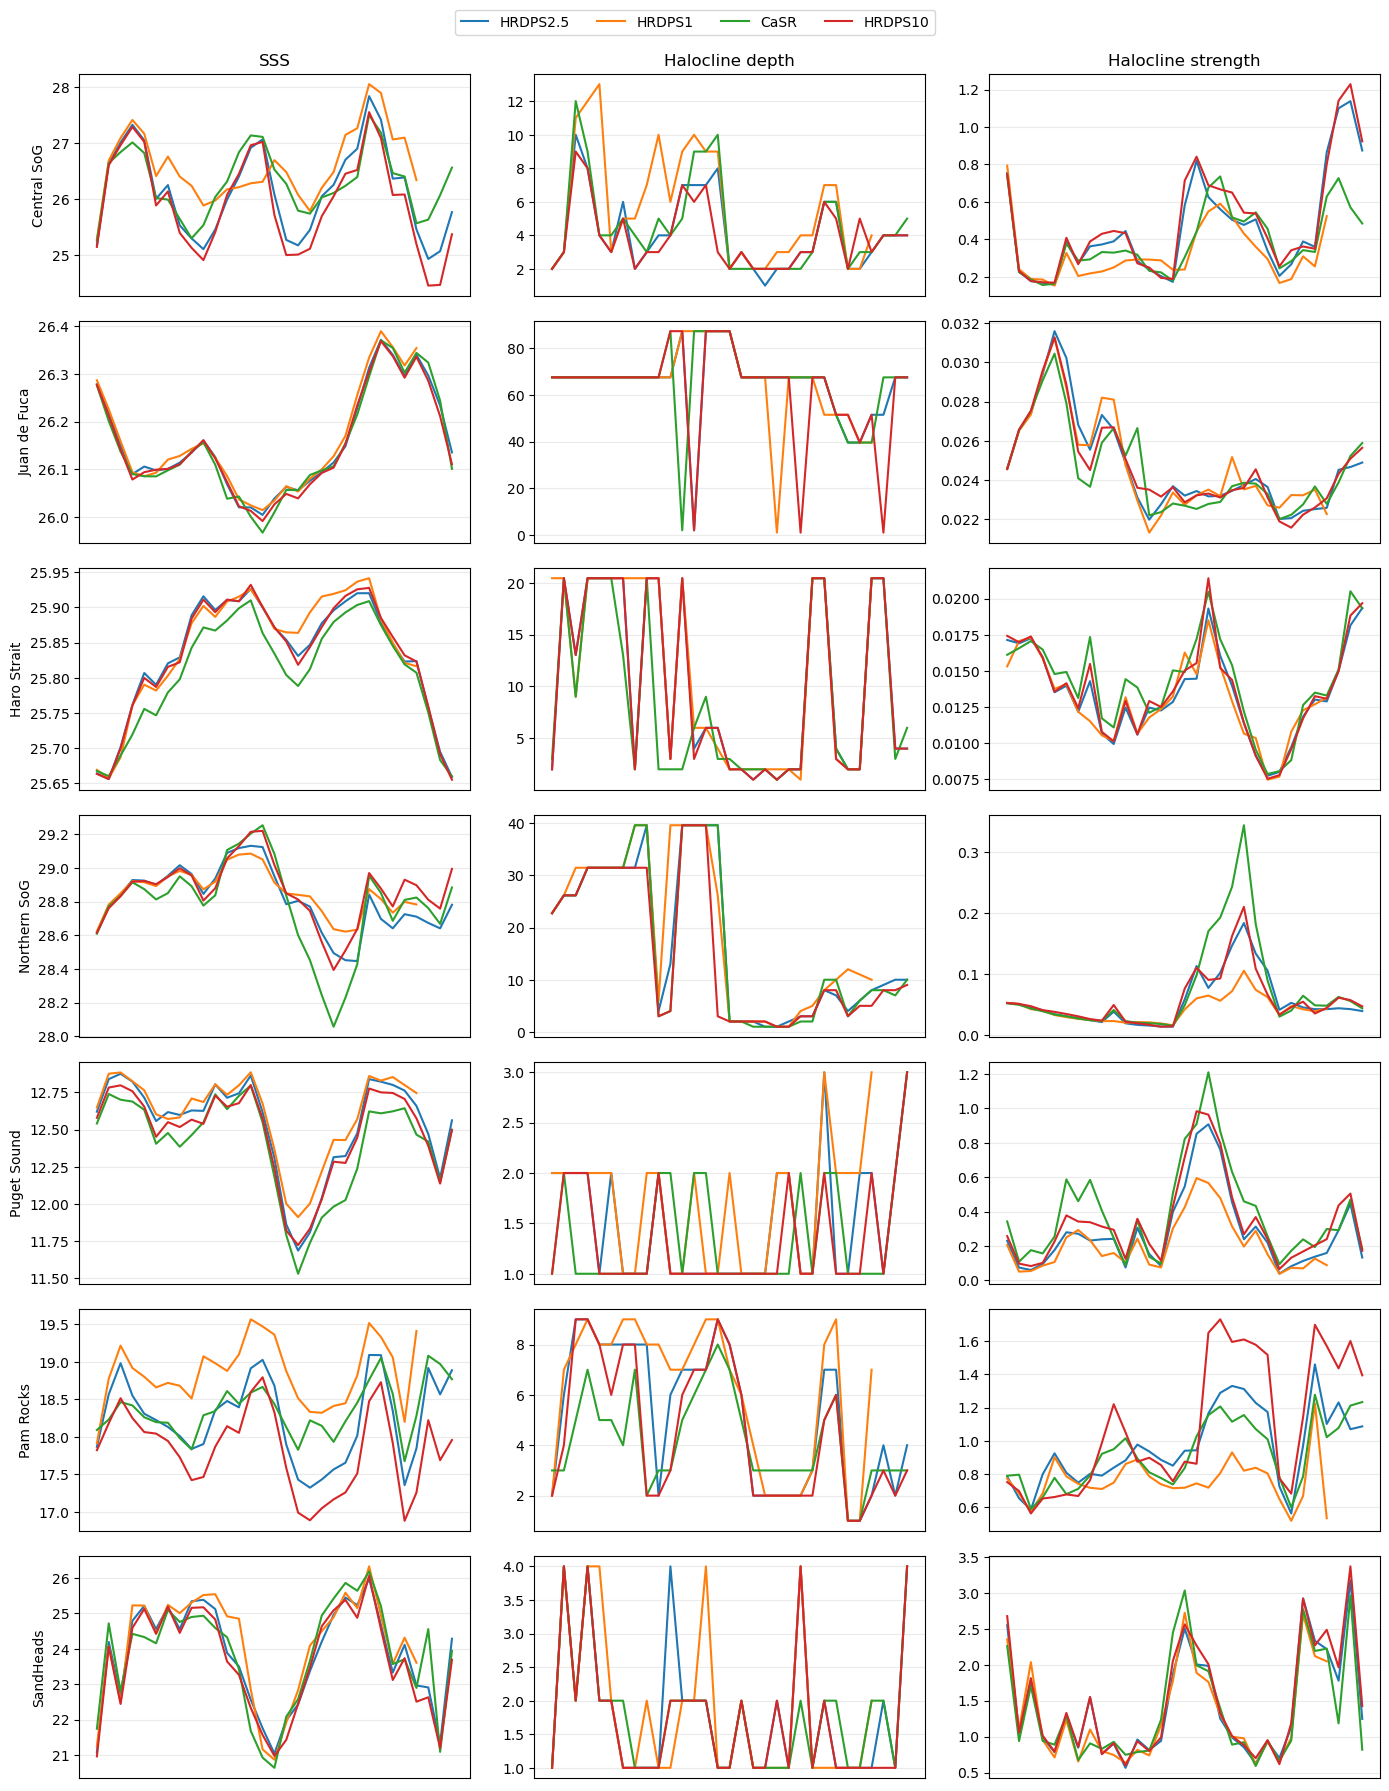

In [3]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# 1. PATH
# ============================================================

DATA_DIR = Path(
    "/home/jqiu/analysis-junqi/"
    "Analysis_Atmospheric_Forcing/"
    "Analysis_results_comparison/"
    "00MMM2023/Data_all_compare/physical"
)


# ============================================================
# 2. SETTINGS
# ============================================================

REGIONS = [
    "Central SoG",
    "Juan de Fuca",
    "Haro Strait",
    "Northern SoG",
    "Puget Sound",
    "Pam Rocks",
    "SandHeads",
]

MODELS = [
    "HRDPS2.5",
    "HRDPS1",
    "CaSR",
    "HRDPS10",
]

VARIABLES = [
    ("SSS", "SSS"),
    ("halocline_depth_m", "Halocline depth"),
    (
        "halocline_strength_psu_per_m",
        "Halocline strength",
    ),
]


# ============================================================
# 3. HELPERS
# ============================================================

def safe_filename(name):
    return name.replace(" ", "_")


# ============================================================
# 4. PLOT
# ============================================================

fig, axes = plt.subplots(
    nrows=len(REGIONS),
    ncols=len(VARIABLES),
    figsize=(14, 18),
)

for row, region in enumerate(REGIONS):

    filename = (
        DATA_DIR /
        f"{safe_filename(region)}_physical.csv"
    )

    print(f"Reading: {filename}")

    df = pd.read_csv(filename)

    # Just use array index as x-axis.
    x = range(len(df))

    for col, (var_name, var_title) in enumerate(VARIABLES):

        ax = axes[row, col]

        for model in MODELS:

            column_name = f"{model}__{var_name}"

            if column_name not in df.columns:
                print(
                    f"WARNING: missing column: "
                    f"{column_name}"
                )
                continue

            ax.plot(
                x,
                df[column_name],
                label=model,
                linewidth=1.5,
            )

        # Column title only on top row
        if row == 0:
            ax.set_title(var_title)

        # Region name only on left column
        if col == 0:
            ax.set_ylabel(region)

        # No time labels
        ax.set_xticks([])

        ax.grid(alpha=0.25)


# ============================================================
# 5. ONE SHARED LEGEND
# ============================================================

handles, labels = axes[0, 0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=len(MODELS),
    bbox_to_anchor=(0.5, 0.995),
)

plt.tight_layout(
    rect=[0, 0, 1, 0.975]
)

plt.show()

### Biological

Reading: /home/jqiu/analysis-junqi/Analysis_Atmospheric_Forcing/Analysis_results_comparison/00MMM2023/Data_all_compare/biology/Central_SoG_biology.csv
Reading: /home/jqiu/analysis-junqi/Analysis_Atmospheric_Forcing/Analysis_results_comparison/00MMM2023/Data_all_compare/biology/Juan_de_Fuca_biology.csv
Reading: /home/jqiu/analysis-junqi/Analysis_Atmospheric_Forcing/Analysis_results_comparison/00MMM2023/Data_all_compare/biology/Haro_Strait_biology.csv
Reading: /home/jqiu/analysis-junqi/Analysis_Atmospheric_Forcing/Analysis_results_comparison/00MMM2023/Data_all_compare/biology/Northern_SoG_biology.csv
Reading: /home/jqiu/analysis-junqi/Analysis_Atmospheric_Forcing/Analysis_results_comparison/00MMM2023/Data_all_compare/biology/Puget_Sound_biology.csv
Reading: /home/jqiu/analysis-junqi/Analysis_Atmospheric_Forcing/Analysis_results_comparison/00MMM2023/Data_all_compare/biology/Pam_Rocks_biology.csv
Reading: /home/jqiu/analysis-junqi/Analysis_Atmospheric_Forcing/Analysis_results_comparison/00

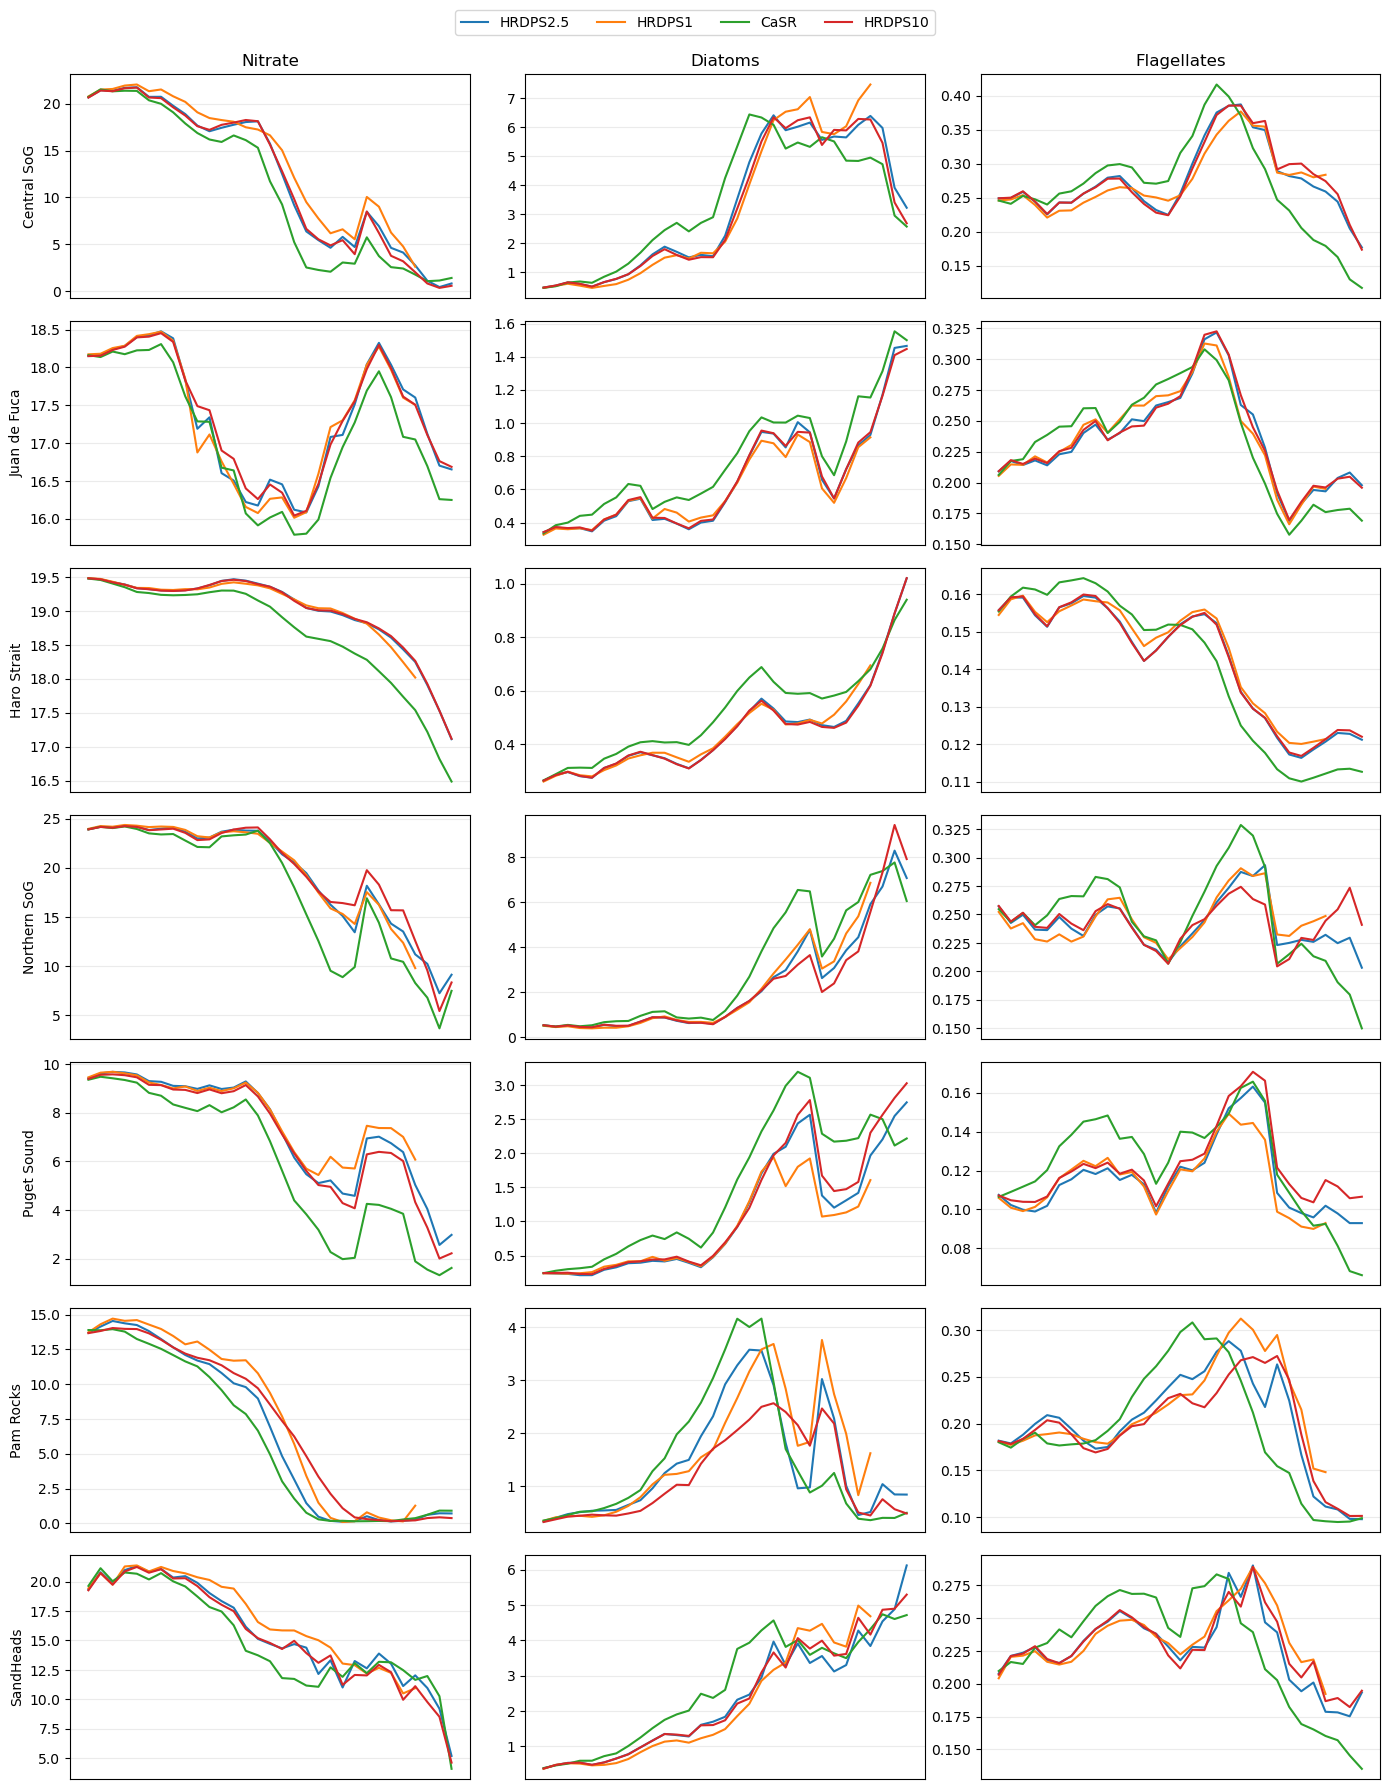

In [5]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# 1. PATH
# ============================================================

DATA_DIR = Path(
    "/home/jqiu/analysis-junqi/"
    "Analysis_Atmospheric_Forcing/"
    "Analysis_results_comparison/"
    "00MMM2023/Data_all_compare/biology"
)


# ============================================================
# 2. SETTINGS
# ============================================================

REGIONS = [
    "Central SoG",
    "Juan de Fuca",
    "Haro Strait",
    "Northern SoG",
    "Puget Sound",
    "Pam Rocks",
    "SandHeads",
]

MODELS = [
    "HRDPS2.5",
    "HRDPS1",
    "CaSR",
    "HRDPS10",
]

VARIABLES = [
    ("nitrate_surface", "Nitrate"),
    ("diatoms_surface", "Diatoms"),
    ("flagellates_surface", "Flagellates"),
]


# ============================================================
# 3. HELPERS
# ============================================================

def safe_filename(name):
    return name.replace(" ", "_")


# ============================================================
# 4. PLOT
# ============================================================

fig, axes = plt.subplots(
    nrows=len(REGIONS),
    ncols=len(VARIABLES),
    figsize=(14, 18),
)

for row, region in enumerate(REGIONS):

    filename = (
        DATA_DIR /
        f"{safe_filename(region)}_biology.csv"
    )

    print(f"Reading: {filename}")

    df = pd.read_csv(filename)

    # 不管时间，直接按数据点序号画
    x = range(len(df))

    for col, (var_name, var_title) in enumerate(VARIABLES):

        ax = axes[row, col]

        for model in MODELS:

            column_name = f"{model}__{var_name}"

            if column_name not in df.columns:
                print(
                    f"WARNING: missing column: "
                    f"{column_name}"
                )
                continue

            ax.plot(
                x,
                df[column_name],
                label=model,
                linewidth=1.5,
            )

        # 第一行写变量名字
        if row == 0:
            ax.set_title(var_title)

        # 第一列写地点名字
        if col == 0:
            ax.set_ylabel(region)

        # 不显示时间/日期
        ax.set_xticks([])

        ax.grid(alpha=0.25)


# ============================================================
# 5. SHARED LEGEND
# ============================================================

handles, labels = axes[0, 0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=len(MODELS),
    bbox_to_anchor=(0.5, 0.995),
)

plt.tight_layout(
    rect=[0, 0, 1, 0.975]
)


# ============================================================
# SHOW
# ============================================================

plt.show()

## Anything fun?

1. `CaSR` nitrate drops quickly. `diatoms` and `flagellates` higher first and then lower. Could be caused by light availability or transparency? 

### CaSR 

#### Find a proper variable

In [7]:
# Prod variables

import xarray as xr

example_path_prod='/ocean/jqiu/results/Flux/flux_00mar23_CaSR/SalishSea_1d_20230301_20230331_prod_T.nc'

example_ds_prod=xr.open_dataset(example_path_prod)

# print(example_ds_prod)


with xr.set_options(display_max_rows=1000):
    print(example_ds_prod)

<xarray.Dataset> Size: 9GB
Dimensions:               (y: 898, x: 398, nvertex: 4, deptht: 40,
                           axis_nbounds: 2, time_counter: 31)
Coordinates:
    nav_lat               (y, x) float32 1MB ...
    nav_lon               (y, x) float32 1MB ...
  * deptht                (deptht) float32 160B 0.5 1.5 2.5 ... 414.5 441.5
    time_centered         (time_counter) datetime64[ns] 248B ...
  * time_counter          (time_counter) datetime64[ns] 248B 2023-03-01T12:00...
Dimensions without coordinates: y, x, nvertex, axis_nbounds
Data variables:
    bounds_nav_lon        (y, x, nvertex) float32 6MB ...
    bounds_nav_lat        (y, x, nvertex) float32 6MB ...
    area                  (y, x) float32 1MB ...
    deptht_bounds         (deptht, axis_nbounds) float32 320B ...
    time_centered_bounds  (time_counter, axis_nbounds) datetime64[ns] 496B ...
    time_counter_bounds   (time_counter, axis_nbounds) datetime64[ns] 496B ...
    PPDIAT                (time_counter, depth

In [8]:
# Chem variables

import xarray as xr

example_path_chem='/ocean/jqiu/results/Flux/flux_00mar23_CaSR/SalishSea_1d_20230301_20230331_chem_T.nc'

example_ds_chem=xr.open_dataset(example_path_chem)

# print(example_ds_prod)


with xr.set_options(display_max_rows=1000):
    print(example_ds_chem)

<xarray.Dataset> Size: 9GB
Dimensions:                     (y: 898, x: 398, nvertex: 4, deptht: 40,
                                 axis_nbounds: 2, time_counter: 31)
Coordinates:
    nav_lat                     (y, x) float32 1MB ...
    nav_lon                     (y, x) float32 1MB ...
  * deptht                      (deptht) float32 160B 0.5 1.5 ... 414.5 441.5
    time_centered               (time_counter) datetime64[ns] 248B ...
  * time_counter                (time_counter) datetime64[ns] 248B 2023-03-01...
Dimensions without coordinates: y, x, nvertex, axis_nbounds
Data variables:
    bounds_nav_lon              (y, x, nvertex) float32 6MB ...
    bounds_nav_lat              (y, x, nvertex) float32 6MB ...
    area                        (y, x) float32 1MB ...
    deptht_bounds               (deptht, axis_nbounds) float32 320B ...
    time_centered_bounds        (time_counter, axis_nbounds) datetime64[ns] 496B ...
    time_counter_bounds         (time_counter, axis_nbounds) da

In [9]:
for name in ['turbidity', 'PAR']:
    print(f"\n{'='*60}")
    print(f"Variable: {name}")
    print(example_ds_chem[name].attrs)


Variable: turbidity
{'standard_name': 'seawater_turbidity', 'long_name': 'Fraser River Turbidity Tracer', 'units': 'NTU', 'online_operation': 'average', 'interval_operation': '40 s', 'interval_write': '1 d', 'cell_methods': 'time: mean (interval: 40 s)', 'cell_measures': 'area: area'}

Variable: PAR
{'standard_name': 'downwelling_photosynthetic_radiative_flux_in_sea_water', 'long_name': 'Photosynthetically Available Radiation', 'units': 'W m-2', 'online_operation': 'average', 'interval_operation': '40 s', 'interval_write': '1 d', 'cell_methods': 'time: mean (interval: 40 s)', 'cell_measures': 'area: area'}


#### PAR at Puget Sound

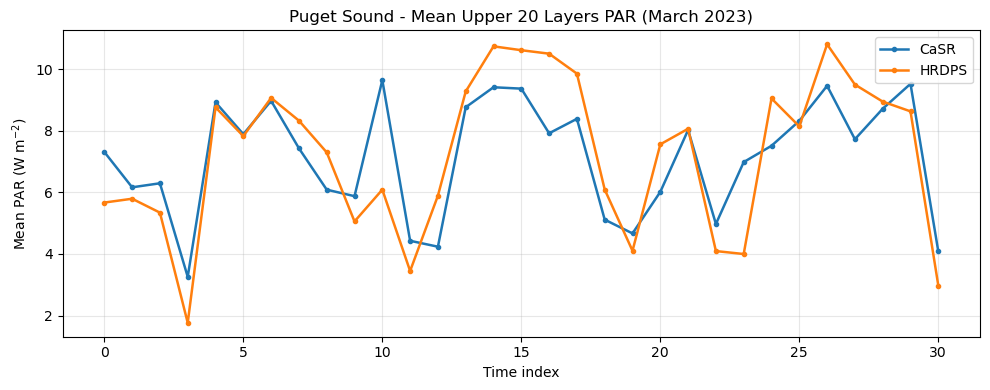

In [10]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Files
# ============================================================
path_casr = (
    '/ocean/jqiu/results/Flux/flux_00mar23_CaSR/'
    'SalishSea_1d_20230301_20230331_chem_T.nc'
)

path_hrdps = (
    '/ocean/jqiu/results/Flux/flux_00mar23_hrdps2.5/'
    'SalishSea_1d_20230301_20230331_chem_T.nc'
)

# ============================================================
# Puget Sound: (j0, j1, i0, i1)
# ============================================================
j0, j1, i0, i1 = 75, 125, 225, 280

casr_ds = xr.open_dataset(path_casr)
hrdps_ds = xr.open_dataset(path_hrdps)

# ============================================================
# Upper 20 layers PAR, all time indices
# ============================================================
casr = casr_ds['PAR'].isel(
    deptht=slice(0, 20),
    y=slice(j0, j1),
    x=slice(i0, i1)
)

hrdps = hrdps_ds['PAR'].isel(
    deptht=slice(0, 20),
    y=slice(j0, j1),
    x=slice(i0, i1)
)

# ============================================================
# Remove zero, negative and NaN values
# ============================================================
casr = casr.where(np.isfinite(casr) & (casr > 0))
hrdps = hrdps.where(np.isfinite(hrdps) & (hrdps > 0))

# ============================================================
# Spatial and vertical mean for each time index
# ============================================================
casr_mean = casr.mean(
    dim=['deptht', 'y', 'x'],
    skipna=True
).values

hrdps_mean = hrdps.mean(
    dim=['deptht', 'y', 'x'],
    skipna=True
).values

# Use index only
time_idx = np.arange(len(casr_mean))

# ============================================================
# Plot
# ============================================================
plt.figure(figsize=(10, 4))

plt.plot(
    time_idx, casr_mean,
    '-o', label='CaSR',
    linewidth=1.8, markersize=3
)

plt.plot(
    time_idx, hrdps_mean,
    '-o', label='HRDPS',
    linewidth=1.8, markersize=3
)

plt.xlabel('Time index')
plt.ylabel('Mean PAR (W m$^{-2}$)')
plt.title('Puget Sound - Mean Upper 20 Layers PAR (March 2023)')

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

casr_ds.close()
hrdps_ds.close()

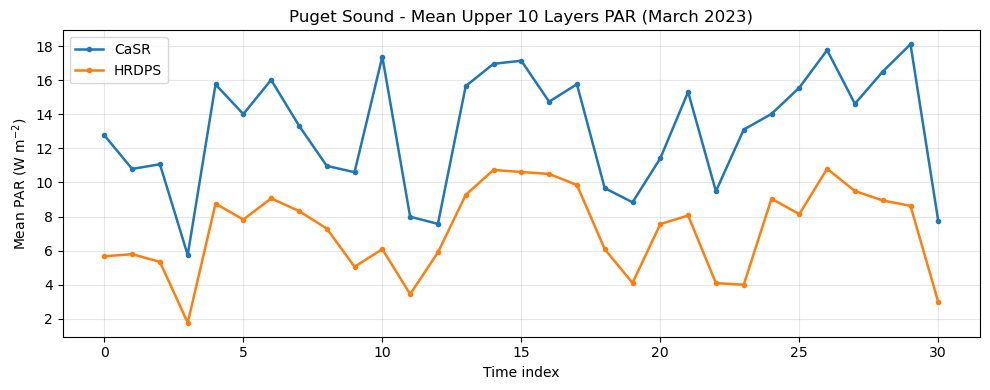

In [11]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Files
# ============================================================
path_casr = (
    '/ocean/jqiu/results/Flux/flux_00mar23_CaSR/'
    'SalishSea_1d_20230301_20230331_chem_T.nc'
)

path_hrdps = (
    '/ocean/jqiu/results/Flux/flux_00mar23_hrdps2.5/'
    'SalishSea_1d_20230301_20230331_chem_T.nc'
)

# ============================================================
# Puget Sound: (j0, j1, i0, i1)
# ============================================================
j0, j1, i0, i1 = 75, 125, 225, 280

casr_ds = xr.open_dataset(path_casr)
hrdps_ds = xr.open_dataset(path_hrdps)

# ============================================================
# Upper 20 layers PAR, all time indices
# ============================================================
casr = casr_ds['PAR'].isel(
    deptht=slice(0, 10),
    y=slice(j0, j1),
    x=slice(i0, i1)
)

hrdps = hrdps_ds['PAR'].isel(
    deptht=slice(0, 20),
    y=slice(j0, j1),
    x=slice(i0, i1)
)

# ============================================================
# Remove zero, negative and NaN values
# ============================================================
casr = casr.where(np.isfinite(casr) & (casr > 0))
hrdps = hrdps.where(np.isfinite(hrdps) & (hrdps > 0))

# ============================================================
# Spatial and vertical mean for each time index
# ============================================================
casr_mean = casr.mean(
    dim=['deptht', 'y', 'x'],
    skipna=True
).values

hrdps_mean = hrdps.mean(
    dim=['deptht', 'y', 'x'],
    skipna=True
).values

# Use index only
time_idx = np.arange(len(casr_mean))

# ============================================================
# Plot
# ============================================================
plt.figure(figsize=(10, 4))

plt.plot(
    time_idx, casr_mean,
    '-o', label='CaSR',
    linewidth=1.8, markersize=3
)

plt.plot(
    time_idx, hrdps_mean,
    '-o', label='HRDPS',
    linewidth=1.8, markersize=3
)

plt.xlabel('Time index')
plt.ylabel('Mean PAR (W m$^{-2}$)')
plt.title('Puget Sound - Mean Upper 10 Layers PAR (March 2023)')

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

casr_ds.close()
hrdps_ds.close()

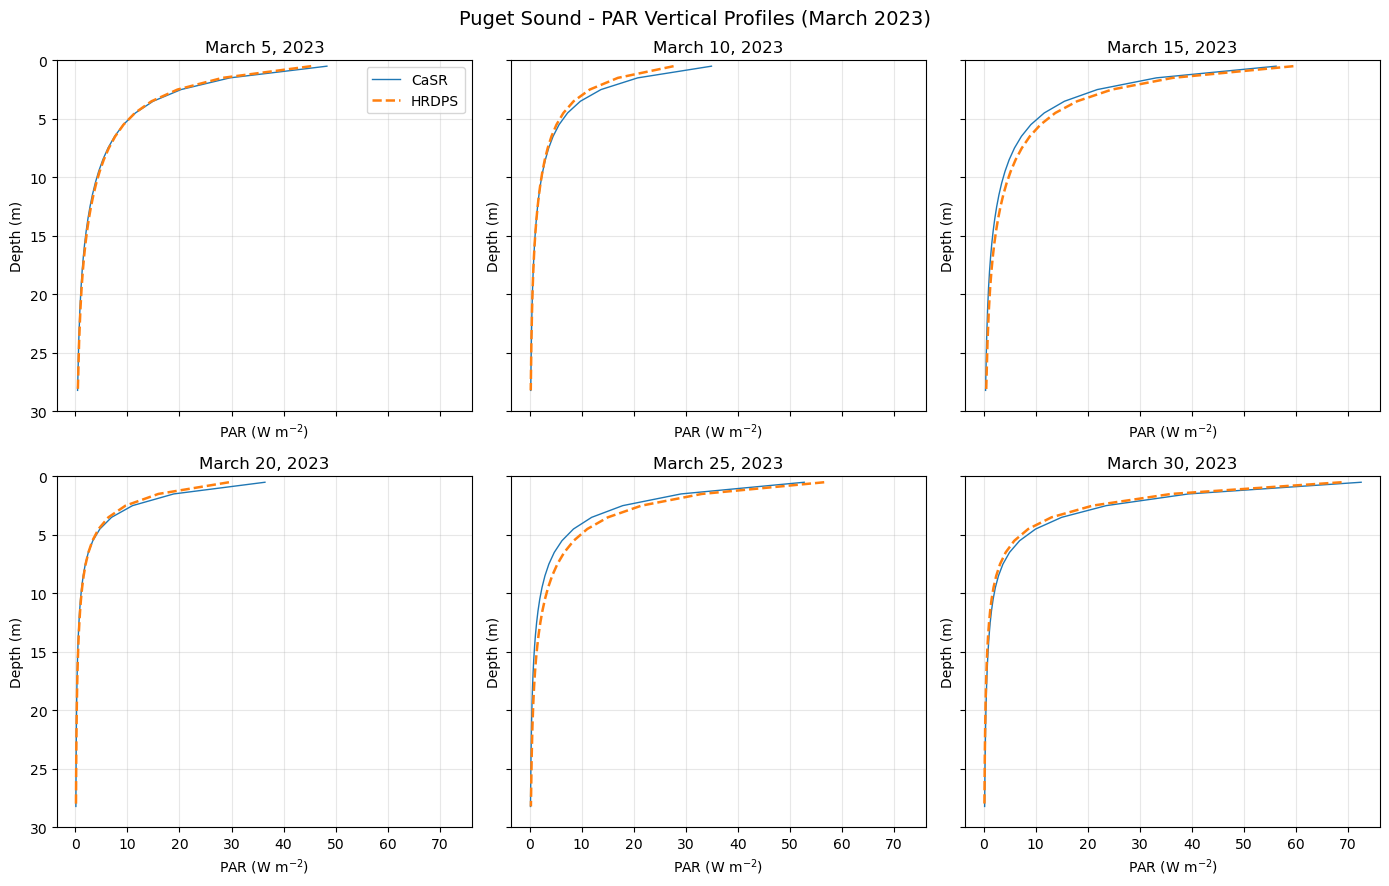

In [18]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Files
# ============================================================
path_casr = (
    '/ocean/jqiu/results/Flux/flux_00mar23_CaSR/'
    'SalishSea_1d_20230301_20230331_chem_T.nc'
)

path_hrdps = (
    '/ocean/jqiu/results/Flux/flux_00mar23_hrdps2.5/'
    'SalishSea_1d_20230301_20230331_chem_T.nc'
)

# ============================================================
# Puget Sound: (j0, j1, i0, i1)
# ============================================================
j0, j1, i0, i1 = 75, 125, 225, 280

# Selected days in March 2023
selected_days = [5, 10, 15, 20, 25, 30]

# Maximum plotting depth
max_depth = 30

# ============================================================
# Open datasets
# ============================================================
casr_ds = xr.open_dataset(path_casr)
hrdps_ds = xr.open_dataset(path_hrdps)

# ============================================================
# Select PAR and calculate spatial mean profiles
# ============================================================
def get_par_profile(ds, day):

    par = ds['PAR'].sel(
        time_counter=f'2023-03-{day:02d}',
        method='nearest'
    ).isel(
        y=slice(j0, j1),
        x=slice(i0, i1)
    )

    # Remove zero, negative and NaN values
    par = par.where(np.isfinite(par) & (par > 0))

    # Spatial mean, keeping depth dimension
    profile = par.mean(
        dim=['y', 'x'],
        skipna=True
    )

    # Select depths between 0 and 175 m
    profile = profile.where(
        profile.deptht <= max_depth,
        drop=True
    )

    return profile.deptht.values, profile.values


# ============================================================
# Plot profiles
# ============================================================
fig, axes = plt.subplots(
    2, 3,
    figsize=(14, 9),
    sharex=True,
    sharey=True
)

axes = axes.flatten()

for ax, day in zip(axes, selected_days):

    depth_casr, par_casr = get_par_profile(casr_ds, day)
    depth_hrdps, par_hrdps = get_par_profile(hrdps_ds, day)

    ax.plot(
        par_casr, depth_casr,
        '-',
        label='CaSR',
        linewidth=1,
        markersize=3
    )

    ax.plot(
        par_hrdps, depth_hrdps,
        '--',
        label='HRDPS',
        linewidth=1.8,
        markersize=3
    )

    ax.set_title(f'March {day}, 2023')
    ax.set_ylim(max_depth, 0)
    ax.grid(alpha=0.3)

    ax.set_xlabel('PAR (W m$^{-2}$)')
    ax.set_ylabel('Depth (m)')

axes[0].legend()

plt.suptitle(
    'Puget Sound - PAR Vertical Profiles (March 2023)',
    fontsize=14
)

plt.tight_layout()
plt.show()

casr_ds.close()
hrdps_ds.close()

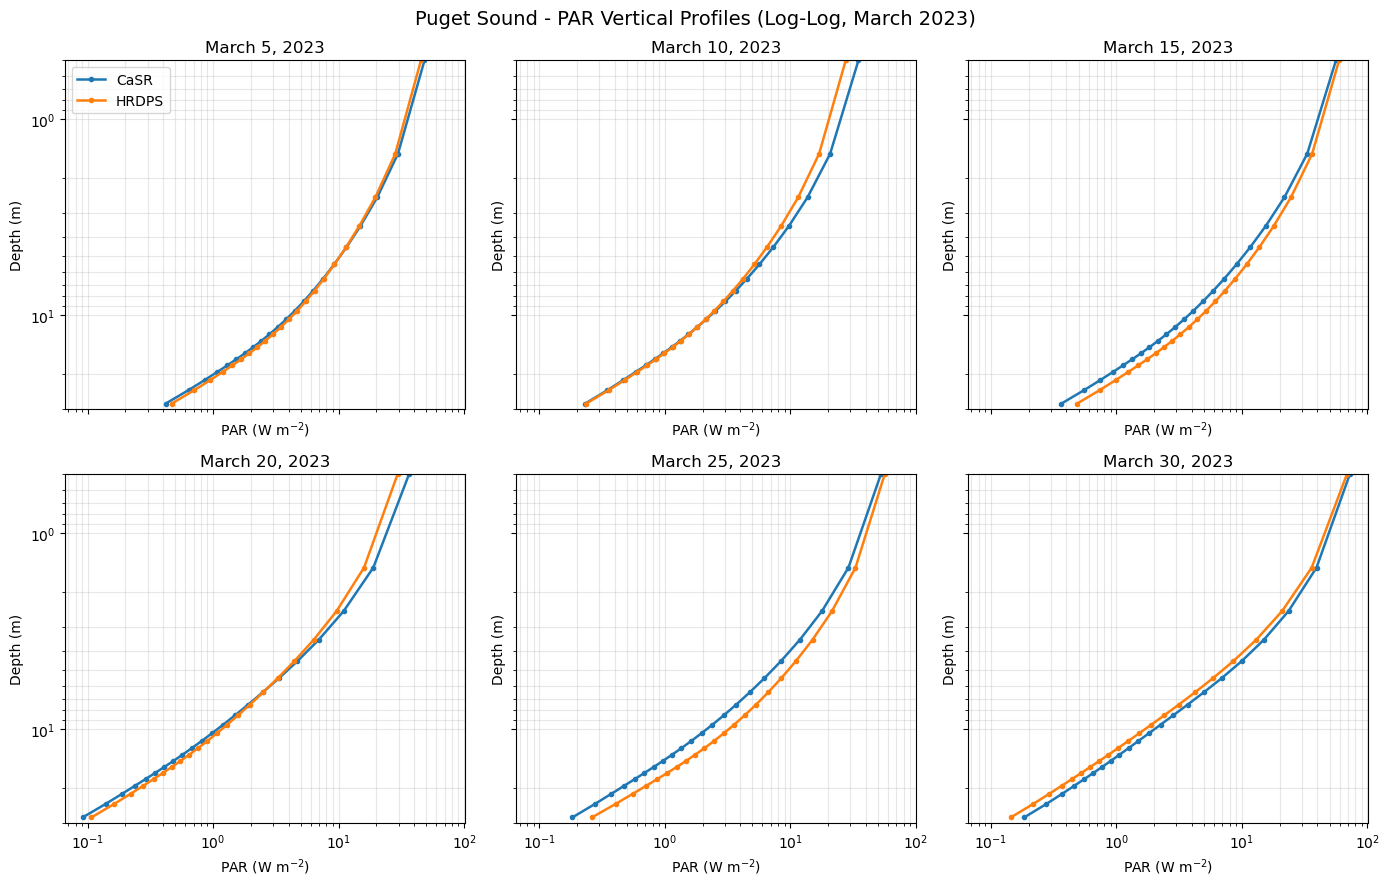

In [19]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Files
# ============================================================
path_casr = (
    '/ocean/jqiu/results/Flux/flux_00mar23_CaSR/'
    'SalishSea_1d_20230301_20230331_chem_T.nc'
)

path_hrdps = (
    '/ocean/jqiu/results/Flux/flux_00mar23_hrdps2.5/'
    'SalishSea_1d_20230301_20230331_chem_T.nc'
)

# ============================================================
# Puget Sound
# ============================================================
j0, j1, i0, i1 = 75, 125, 225, 280

selected_days = [5, 10, 15, 20, 25, 30]
max_depth = 30

# ============================================================
# Open datasets
# ============================================================
casr_ds = xr.open_dataset(path_casr)
hrdps_ds = xr.open_dataset(path_hrdps)

# ============================================================
# Get PAR profile
# ============================================================
def get_par_profile(ds, day):

    par = ds['PAR'].sel(
        time_counter=f'2023-03-{day:02d}',
        method='nearest'
    ).isel(
        y=slice(j0, j1),
        x=slice(i0, i1)
    )

    # Remove zero, negative, NaN and infinity
    par = par.where(np.isfinite(par) & (par > 0))

    # Spatial mean
    profile = par.mean(
        dim=['y', 'x'],
        skipna=True
    )

    # Upper 30 m
    profile = profile.where(
        profile.deptht <= max_depth,
        drop=True
    )

    return profile.deptht.values, profile.values


# ============================================================
# Plot
# ============================================================
fig, axes = plt.subplots(
    2, 3,
    figsize=(14, 9),
    sharex=True,
    sharey=True
)

axes = axes.flatten()

for ax, day in zip(axes, selected_days):

    depth_casr, par_casr = get_par_profile(casr_ds, day)
    depth_hrdps, par_hrdps = get_par_profile(hrdps_ds, day)

    # Log-log plots
    ax.loglog(
        par_casr, depth_casr,
        '-o', label='CaSR',
        linewidth=1.8, markersize=3
    )

    ax.loglog(
        par_hrdps, depth_hrdps,
        '-o', label='HRDPS',
        linewidth=1.8, markersize=3
    )

    ax.set_title(f'March {day}, 2023')

    # Invert depth axis
    ax.set_ylim(max_depth, 0.5)

    ax.set_xlabel('PAR (W m$^{-2}$)')
    ax.set_ylabel('Depth (m)')

    ax.grid(alpha=0.3, which='both')

axes[0].legend()

plt.suptitle(
    'Puget Sound - PAR Vertical Profiles (Log-Log, March 2023)',
    fontsize=14
)

plt.tight_layout()
plt.show()

casr_ds.close()
hrdps_ds.close()

#### Light flux

Making sure that the total flux of light is similar between models. If so, the light availability difference can be attributed to physical processes, probably by mixing.

Puget Sound coordinate from: https://www.geonames.org/5807517

In [14]:
import xarray as xr
import numpy as np

# ============================================================
# Paths
# ============================================================
path_CaSR = '/ocean/jqiu/forcings/CaSR/CaSR_y2023m03d01.nc'

path_HRDPS = (
    '/results/forcing/atmospheric/continental2.5/'
    'nemo_forcing/hrdps_y2023m03d01.nc'
)

variable_therm_radiation = 'therm_rad'

# ============================================================
# Target coordinates
# ============================================================
target_lat = 47.8332
target_lon = -122.4346

# ============================================================
# Find nearest grid point
# ============================================================
def find_nearest_grid_point(path, name):

    with xr.open_dataset(path) as ds:

        print(f"\n{'='*60}")
        print(name)
        print(f"{'='*60}")

        lat = ds['nav_lat'].values
        lon = ds['nav_lon'].values

        # Handle longitude convention (0-360 or -180-180)
        lon = (lon + 180) % 360 - 180

        # Approximate geographical distance
        distance = (
            (lat - target_lat)**2 +
            ((lon - target_lon) *
             np.cos(np.deg2rad(target_lat)))**2
        )

        distance = np.where(np.isfinite(distance), distance, np.inf)

        # Find nearest grid index
        j, i = np.unravel_index(
            np.argmin(distance),
            distance.shape
        )

        print(f"Target lat: {target_lat}")
        print(f"Target lon: {target_lon}")

        print(f"\nNearest grid index:")
        print(f"  y = {j}")
        print(f"  x = {i}")

        print(f"\nActual grid coordinates:")
        print(f"  Latitude  = {lat[j, i]:.6f}")
        print(f"  Longitude = {lon[j, i]:.6f}")

        # Check radiation variable
        if variable_therm_radiation in ds:
            print(f"\nRadiation variable:")
            print(ds[variable_therm_radiation].attrs)

        return j, i


# ============================================================
# Run
# ============================================================
casr_j, casr_i = find_nearest_grid_point(path_CaSR, 'CaSR')

hrdps_j, hrdps_i = find_nearest_grid_point(path_HRDPS, 'HRDPS')

print("\nSummary:")
print(f"CaSR  index: y={casr_j}, x={casr_i}")
print(f"HRDPS index: y={hrdps_j}, x={hrdps_i}")


CaSR
Target lat: 47.8332
Target lon: -122.4346

Nearest grid index:
  y = 39
  x = 34

Actual grid coordinates:
  Latitude  = 47.864235
  Longitude = -122.447205

Radiation variable:
{'units': 'W/m^2'}

HRDPS
Target lat: 47.8332
Target lon: -122.4346

Nearest grid index:
  y = 59
  x = 127

Actual grid coordinates:
  Latitude  = 47.826828
  Longitude = -122.433704

Radiation variable:
{'GRIB_paramId': np.int64(175), 'GRIB_dataType': 'af', 'GRIB_numberOfPoints': '43700LL', 'GRIB_typeOfLevel': 'surface', 'GRIB_stepUnits': np.int64(1), 'GRIB_stepType': 'accum', 'GRIB_gridType': 'rotated_ll', 'GRIB_NV': np.int64(0), 'GRIB_Nx': '230LL', 'GRIB_Ny': '190LL', 'GRIB_angleOfRotationInDegrees': np.float64(0.0), 'GRIB_cfName': 'unknown', 'GRIB_cfVarName': 'strd', 'GRIB_gridDefinitionDescription': 'Rotated latitude/longitude', 'GRIB_iDirectionIncrementInDegrees': np.float64(0.0225), 'GRIB_iScansNegatively': np.int64(0), 'GRIB_jDirectionIncrementInDegrees': np.float64(0.0225), 'GRIB_jPointsAreConse

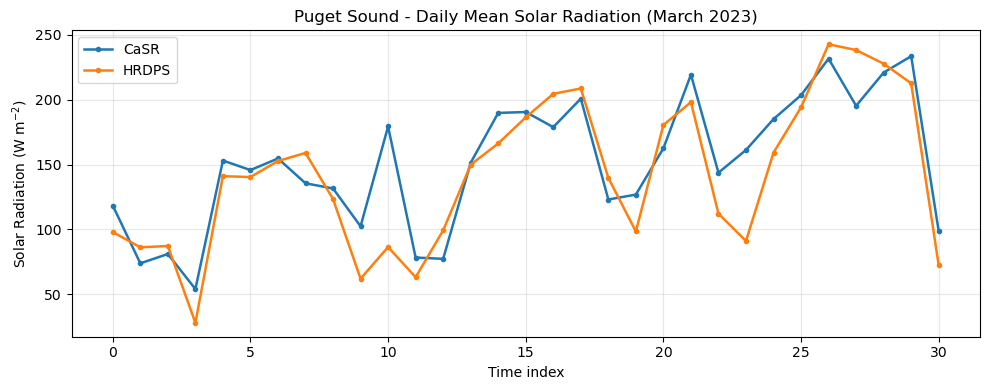


Daily Mean Solar Radiation (W/m2)
March 01: CaSR =   118.37, HRDPS =    97.97, Diff =    20.41
March 02: CaSR =    73.90, HRDPS =    86.26, Diff =   -12.36
March 03: CaSR =    81.10, HRDPS =    87.23, Diff =    -6.13
March 04: CaSR =    54.08, HRDPS =    28.10, Diff =    25.98
March 05: CaSR =   153.07, HRDPS =   141.04, Diff =    12.03
March 06: CaSR =   145.71, HRDPS =   140.35, Diff =     5.36
March 07: CaSR =   154.67, HRDPS =   152.70, Diff =     1.97
March 08: CaSR =   135.56, HRDPS =   158.93, Diff =   -23.38
March 09: CaSR =   131.57, HRDPS =   123.40, Diff =     8.17
March 10: CaSR =   102.39, HRDPS =    62.08, Diff =    40.31
March 11: CaSR =   179.31, HRDPS =    86.43, Diff =    92.88
March 12: CaSR =    78.37, HRDPS =    63.21, Diff =    15.16
March 13: CaSR =    77.35, HRDPS =    99.23, Diff =   -21.88
March 14: CaSR =   151.35, HRDPS =   149.85, Diff =     1.50
March 15: CaSR =   189.75, HRDPS =   166.22, Diff =    23.52
March 16: CaSR =   190.44, HRDPS =   186.34, Diff 

In [15]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
import os

# ============================================================
# Paths
# ============================================================
dir_CaSR = '/ocean/jqiu/forcings/CaSR/'

dir_HRDPS = (
    '/results/forcing/atmospheric/continental2.5/'
    'nemo_forcing/'
)

variable_solar = 'solar'

# ============================================================
# Grid indices
# ============================================================
casr_j, casr_i = 39, 34
hrdps_j, hrdps_i = 59, 127

# ============================================================
# Daily mean solar radiation
# ============================================================
days = np.arange(1, 32)

casr_daily = []
hrdps_daily = []

for day in days:

    date_str = f'2023m03d{day:02d}'

    path_CaSR = os.path.join(
        dir_CaSR,
        f'CaSR_y{date_str}.nc'
    )

    path_HRDPS = os.path.join(
        dir_HRDPS,
        f'hrdps_y{date_str}.nc'
    )

    # --------------------------------------------------------
    # CaSR
    # --------------------------------------------------------
    with xr.open_dataset(path_CaSR) as ds:

        solar = ds[variable_solar].isel(
            y=casr_j,
            x=casr_i
        )

        values = np.asarray(solar.values, dtype=float)

        values = values[
            np.isfinite(values) &
            (values >= 0) &
            (values < 1e10)
        ]

        casr_daily.append(
            np.mean(values) if len(values) > 0 else np.nan
        )

    # --------------------------------------------------------
    # HRDPS
    # --------------------------------------------------------
    with xr.open_dataset(path_HRDPS) as ds:

        solar = ds[variable_solar].isel(
            y=hrdps_j,
            x=hrdps_i
        )

        values = np.asarray(solar.values, dtype=float)

        values = values[
            np.isfinite(values) &
            (values >= 0) &
            (values < 1e10)
        ]

        hrdps_daily.append(
            np.mean(values) if len(values) > 0 else np.nan
        )

# ============================================================
# Convert to arrays
# ============================================================
casr_daily = np.array(casr_daily)
hrdps_daily = np.array(hrdps_daily)

# ============================================================
# Plot
# ============================================================
plt.figure(figsize=(10, 4))

plt.plot(
    days - 1, casr_daily,
    '-o', label='CaSR',
    linewidth=1.8, markersize=3
)

plt.plot(
    days - 1, hrdps_daily,
    '-o', label='HRDPS',
    linewidth=1.8, markersize=3
)

plt.xlabel('Time index')
plt.ylabel('Solar Radiation (W m$^{-2}$)')
plt.title(
    'Puget Sound - Daily Mean Solar Radiation (March 2023)'
)

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================================
# Print results
# ============================================================
print('\nDaily Mean Solar Radiation (W/m2)')
print('=' * 45)

for day, c, h in zip(days, casr_daily, hrdps_daily):
    print(
        f'March {day:02d}: '
        f'CaSR = {c:8.2f}, '
        f'HRDPS = {h:8.2f}, '
        f'Diff = {c-h:8.2f}'
    )

#### Wind stress

In [12]:
# Sbfx variables

import xarray as xr

example_path_sbfx='/ocean/jqiu/results/Flux/flux_00mar23_CaSR/SalishSea_1d_20230301_20230331_sbfx_T.nc'

example_ds_sbfx=xr.open_dataset(example_path_sbfx)

# print(example_ds_prod)


with xr.set_options(display_max_rows=1000):
    print(example_ds_sbfx)

<xarray.Dataset> Size: 237MB
Dimensions:               (y: 898, x: 398, nvertex: 4, time_counter: 31,
                           axis_nbounds: 2)
Coordinates:
    nav_lat               (y, x) float32 1MB ...
    nav_lon               (y, x) float32 1MB ...
    time_centered         (time_counter) datetime64[ns] 248B ...
  * time_counter          (time_counter) datetime64[ns] 248B 2023-03-01T12:00...
Dimensions without coordinates: y, x, nvertex, axis_nbounds
Data variables:
    bounds_nav_lon        (y, x, nvertex) float32 6MB ...
    bounds_nav_lat        (y, x, nvertex) float32 6MB ...
    area                  (y, x) float32 1MB ...
    time_centered_bounds  (time_counter, axis_nbounds) datetime64[ns] 496B ...
    time_counter_bounds   (time_counter, axis_nbounds) datetime64[ns] 496B ...
    longwave_heat_flux    (time_counter, y, x) float32 44MB ...
    sensible_heat_flux    (time_counter, y, x) float32 44MB ...
    latent_heat_flux      (time_counter, y, x) float32 44MB ...
    em

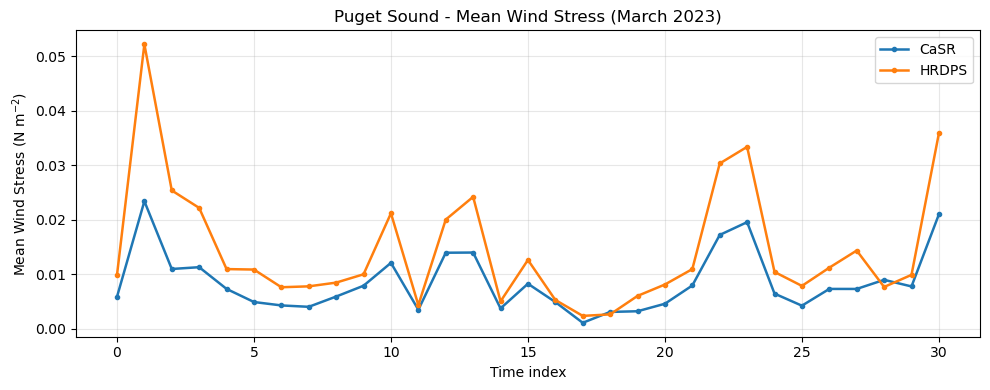

In [13]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Files
# ============================================================
path_casr = (
    '/ocean/jqiu/results/Flux/flux_00mar23_CaSR/'
    'SalishSea_1d_20230301_20230331_sbfx_T.nc'
)

path_hrdps = (
    '/ocean/jqiu/results/Flux/flux_00mar23_hrdps2.5/'
    'SalishSea_1d_20230301_20230331_sbfx_T.nc'
)

# ============================================================
# Puget Sound: (j0, j1, i0, i1)
# ============================================================
j0, j1, i0, i1 = 75, 125, 225, 280

casr_ds = xr.open_dataset(path_casr)
hrdps_ds = xr.open_dataset(path_hrdps)

# ============================================================
# Wind stress, all time indices
# ============================================================
casr = casr_ds['wind stress'].isel(
    y=slice(j0, j1),
    x=slice(i0, i1)
)

hrdps = hrdps_ds['wind stress'].isel(
    y=slice(j0, j1),
    x=slice(i0, i1)
)

# ============================================================
# Remove invalid values
# ============================================================
casr = casr.where(np.isfinite(casr))
hrdps = hrdps.where(np.isfinite(hrdps))

# ============================================================
# Spatial mean for each time index
# ============================================================
casr_mean = casr.mean(
    dim=['y', 'x'],
    skipna=True
).values

hrdps_mean = hrdps.mean(
    dim=['y', 'x'],
    skipna=True
).values

# Use index only
time_idx = np.arange(len(casr_mean))

# ============================================================
# Plot
# ============================================================
plt.figure(figsize=(10, 4))

plt.plot(
    time_idx, casr_mean,
    '-o', label='CaSR',
    linewidth=1.8, markersize=3
)

plt.plot(
    time_idx, hrdps_mean,
    '-o', label='HRDPS',
    linewidth=1.8, markersize=3
)

plt.xlabel('Time index')
plt.ylabel('Mean Wind Stress (N m$^{-2}$)')
plt.title('Puget Sound - Mean Wind Stress (March 2023)')

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

casr_ds.close()
hrdps_ds.close()